# Проект. Яндекс Афиша

- Автор: Козлова Екатерина
- Дата: 09.04.2026 г. - 10.04.2026 г.

## Цели и задачи проекта 

**Цель проекта** - провести исследовательский анализ данных о бронировании билетов на сервисе Яндекс Афиша за период с 1 июня по 31 октября 2024 года, а также проанализировать различия в поведении пользователей на мобильных и стационарных устройствах.

**Задачи проекта**:
1. Загрузка данных и знакомство с ними
2. Предобработка данных и подготовка их к исследованию:
* Проверка данных на пропуски
* Изучение значений в ключевых столбцах
* Проверка явных и неявных дубликатов
* Преобразование типов данных
* Создание новых столбцов
3. Исследовательский анализ данных:
* Анализ распределения заказов по сегментам и их сезонные изменения
* Осенняя активность пользователей
4. Статистический анализ данных
5. Общий вывод и рекомендации

## Описание данных

Данные о бронировании билетов на сервисе Яндекс Афиша за период с 1 июня по 31 октября 2024 года представлены в двух датасетах: final_tickets_orders_df.csv и final_tickets_events_df.csv.

Датасет **final_tickets_orders_df.csv** включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных:
* order_id — уникальный идентификатор заказа.
* user_id — уникальный идентификатор пользователя.
* created_dt_msk — дата создания заказа (московское время).
* created_ts_msk — дата и время создания заказа (московское время).
* event_id — идентификатор мероприятия из таблицы events.
* cinema_circuit — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
* age_limit — возрастное ограничение мероприятия.
* currency_code — валюта оплаты, например rub для российских рублей.
* device_type_canonical — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
* revenue — выручка от заказа.
* service_name — название билетного оператора.
* tickets_count — количество купленных билетов.
* total — общая сумма заказа.
В данные также был добавлен столбец days_since_prev с количеством дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск.


Датасет **final_tickets_events_df** содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия: 
* event_id — уникальный идентификатор мероприятия.
* event_name — название мероприятия. Аналог поля event_name_code из исходной базы данных.
* event_type_description — описание типа мероприятия.
* event_type_main — основной тип мероприятия: театральная постановка, концерт и так далее.
* organizers — организаторы мероприятия.
* region_name — название региона.
* city_name — название города.
* venue_id — уникальный идентификатор площадки.
* venue_name — название площадки.
* venue_address — адрес площадки.

Также имеется дополнительный датасет **final_tickets_tenge_df.csv**, который содержит данные о курсе тенге к российскому рублю за 2024 год:
* nominal — номинал (100 тенге).
* data — дата.
* curs — курс тенге к рублю.
* cdx — обозначение валюты (kzt).

### Содержимое проекта

* [Знакомство данных и знакомство с ними](#1bullet) 
* [Предобработка данных и подготовка их к исследованию](#2bullet)
* [Исследовательский анализ данных](#3bullet)
* [Статистический анализ данных](#4bullet)
* [Общий вывод и рекомендации](#5bullet)

## Загрузка данных и знакомство с ними

In [1]:
# Загрузим необходимые библиотеки, которые будут использованы в настоящем проекте
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu

In [2]:
orders_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv') 
events_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv') 
tenge_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv') 

orders_df.info()
orders_df.head()

In [3]:
events_df.info()
events_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [4]:
tenge_df.info()
tenge_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


На основе первичных данных можно сделать следующие выводы:

    1. Датасет orders_df состоит из 290 849 записей и 14 столбцов. Единственный столбец с пропусками — days_since_prev: 21940 пропусков (≈7,5 % от общего числа записей). Остальные столбцы полностью заполнены. По типу данных столбцов на первый взгляд все хорошо, можно лишь преобразовать столбцы created_dt_msk и created_ts_msk к типу datetime. Названия столбцов соответствуют стилистике и понятны по смыслу.
    
    2. Датасет events_df состоит из 22427 записей и 11 столбцов. Все столбцы заполнены, пропуски отсутствуют. Типы данных корректные. Названия столбцов соответствуют стилистике и понятны по смыслу.
    
    3. Датасет tenge_df состоит из 357 записей и 4 столбцов. По типам данных в трех столбцах все верно, а столбец data лучше преобразовать в datetime. Названия столбцов соответствуют стилистике и понятны по смыслу.

## Предобработка данных и подготовка их к исследованию

Для дальнейшего удобства в работе с данными, соединим 2 датасета в единый датасет (с данными о заказах и событиях)

In [5]:
afisha_df = pd.merge(
    orders_df,
    events_df,
    on='event_id',
    how='left' 
)
afisha_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290849 entries, 0 to 290848
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                290849 non-null  int64  
 1   user_id                 290849 non-null  object 
 2   created_dt_msk          290849 non-null  object 
 3   created_ts_msk          290849 non-null  object 
 4   event_id                290849 non-null  int64  
 5   cinema_circuit          290849 non-null  object 
 6   age_limit               290849 non-null  int64  
 7   currency_code           290849 non-null  object 
 8   device_type_canonical   290849 non-null  object 
 9   revenue                 290849 non-null  float64
 10  service_name            290849 non-null  object 
 11  tickets_count           290849 non-null  int64  
 12  total                   290849 non-null  float64
 13  days_since_prev         268909 non-null  float64
 14  event_name          

In [6]:
# создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
temp_1 = afisha_df.copy() 
len(temp_1)

290849

In [7]:
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]

    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    # Форматируем при выводе через Styler
    return (missing_stats
            .style
            .format({'Доля пропусков': '{:.4f}'}))

show_missing_stats(afisha_df)

,Кол-во пропусков,Доля пропусков
days_since_prev,21940,0.0754
event_name,238,0.0008
event_type_description,238,0.0008
event_type_main,238,0.0008
organizers,238,0.0008
region_name,238,0.0008
city_name,238,0.0008
city_id,238,0.0008
venue_id,238,0.0008
venue_name,238,0.0008


Мы видим, что наибольшее количество пропусков находится в столбце days_since_prev: 21940 пропусков, что составляет ~7,5%. Возможно, данные о промежутке времени между событиями не были собраны для значительной части записей или же это техническая ошибка. Пропуски в данном столбце изучим.

Остальные столбцы имеют по 238 пропусков, что составляет ~0.08%. Учитывая их низкую долю, по отношению к остальным данным, их можно удалить.

In [8]:
afisha_df = afisha_df.dropna(subset=['event_name', 'event_type_description', 'event_type_main', 
                                     'organizers', 'region_name', 'city_name', 'city_id', 
                                     'venue_id', 'venue_name', 'venue_address']).reset_index(drop=True)

In [9]:
afisha_df[afisha_df['days_since_prev'].isna()]

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,40efeb04-81b7-4135-b41f-708ff00cc64c,событие,выставки,№4850,Каменевский регион,Глиногорск,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4"
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,2f638715-8844-466c-b43f-378a627c419f,выставка,другое,№5049,Североярская область,Озёрск,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8"
6,6636941,00096d1f542ab2b,2024-08-15,2024-08-15 16:48:48,201953,нет,16,rub,desktop,917.83,...,2f98d69f-4e60-4ffc-8f16-e539383526b1,спектакль,театр,№1825,Каменевский регион,Глиногорск,213.0,4035.0,"Выставка ремесел ""Платформа"" Групп","алл. Горняцкая, д. 573"
7,4657981,000a55a418c128c,2024-09-29,2024-09-29 19:39:12,265857,нет,12,rub,mobile,47.78,...,0d876e01-851e-458b-ba61-753e0e0c4063,спектакль,театр,№1637,Поленовский край,Дальнозолотск,18.0,3159.0,"Клуб начинающих писателей ""Таблицы"" Групп","ул. О.Кошевого, д. 7"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290565,2668813,fff13b79bd47d7c,2024-07-16,2024-07-16 22:17:10,536131,нет,16,rub,mobile,297.04,...,3ccd92b9-5450-40a1-a7a8-5075cf90cc6a,событие,другое,№3049,Каменевский регион,Глиногорск,213.0,944.0,"Ремесленный центр ""Мороз"" Лимитед","ул. Черноморская, д. 32 к. 9/6"
290574,2440931,fff32fc9ad0f9f6,2024-08-15,2024-08-15 14:36:28,291439,нет,18,rub,desktop,779.99,...,9dbaefe5-56de-4b32-b991-7e9e4d04b702,концерт,стендап,№2455,Каменевский регион,Глиногорск,213.0,894.0,"Научный центр ""Кубок"" и партнеры","наб. Мелиоративная, д. 7 стр. 93"
290576,5114702,fffcd3dde79eb2c,2024-06-20,2024-06-20 19:57:25,529500,нет,16,rub,desktop,367.56,...,9303405c-c6df-4852-8768-73479f55dc25,концерт,концерты,№2121,Каменевский регион,Глиногорск,213.0,944.0,"Ремесленный центр ""Мороз"" Лимитед","ул. Черноморская, д. 32 к. 9/6"
290609,5526067,fffeeb3c120cf0b,2024-09-24,2024-09-24 10:07:42,454526,нет,18,rub,desktop,661.53,...,6f4c6a50-0106-407b-8f54-332c740b01da,шоу,стендап,№998,Широковская область,Ягодиновка,239.0,2449.0,"Гильдия художников ""Флит"" Инк","пр. Макарова, д. 4"


Из представленных данных видно, что пропуски в days_since_prev не связаны с пропусками в других столбцах (все ключевые поля заполнены). Данные содержат UUID‑идентификаторы для order_id и event_name — это подтверждает целостность записей, каждая строка представляет полноценный заказ с полной информацией о событии, месте проведения и т.д. Пропуски, скорее всего, имеют логическую природу: для части заказов нет информации о предыдущем визите/событии. Оставим данные пропуски без изменений.

In [10]:
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]

    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    # Форматируем при выводе через Styler
    return (missing_stats
            .style
            .format({'Доля пропусков': '{:.4f}'}))

show_missing_stats(afisha_df)

,Кол-во пропусков,Доля пропусков
days_since_prev,21913,0.0754


In [11]:
afisha_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                290611 non-null  int64  
 1   user_id                 290611 non-null  object 
 2   created_dt_msk          290611 non-null  object 
 3   created_ts_msk          290611 non-null  object 
 4   event_id                290611 non-null  int64  
 5   cinema_circuit          290611 non-null  object 
 6   age_limit               290611 non-null  int64  
 7   currency_code           290611 non-null  object 
 8   device_type_canonical   290611 non-null  object 
 9   revenue                 290611 non-null  float64
 10  service_name            290611 non-null  object 
 11  tickets_count           290611 non-null  int64  
 12  total                   290611 non-null  float64
 13  days_since_prev         268698 non-null  float64
 14  event_name          

Теперь изучим значения в ключевых столбцах и при обнаружении ошибок обработаем их.
Для категориальных значений изучим, какие категории присутствуют в данных. Проверим, встречаются ли значения, которые могут обозначать пропуски в данных или отсутствие информации. Проведем нормализацию данных, если это необходимо.

In [12]:
for column_name in ['currency_code', 'device_type_canonical', 'service_name',
    'event_type_description', 'event_type_main', 'organizers',
    'region_name', 'city_name', 'venue_name', 'cinema_circuit']:
    print(f"Колонка: {column_name}")
    
    unique_values = afisha_df[column_name].unique()
    print(f"Уникальные значения: {unique_values}")
    
    unique_count = afisha_df[column_name].nunique()
    print(f"Количество уникальных значений: {unique_count}")

Колонка: currency_code
Уникальные значения: ['rub' 'kzt']
Количество уникальных значений: 2
Колонка: device_type_canonical
Уникальные значения: ['mobile' 'desktop']
Количество уникальных значений: 2
Колонка: service_name
Уникальные значения: ['Край билетов' 'Мой билет' 'За билетом!' 'Лови билет!'
 'Билеты без проблем' 'Облачко' 'Лучшие билеты' 'Прачечная' 'Быстробилет'
 'Дом культуры' 'Весь в билетах' 'Билеты в руки' 'Тебе билет!'
 'Show_ticket' 'Городской дом культуры' 'Яблоко' 'Билет по телефону'
 'Выступления.ру' 'Росбилет' 'Шоу начинается!' 'Мир касс' 'Восьмёрка'
 'Телебилет' 'Crazy ticket!' 'Реестр' 'Быстрый кассир' 'КарандашРУ'
 'Радио ticket' 'Дырокол' 'Вперёд!' 'Кино билет' 'Цвет и билет' 'Зе Бест!'
 'Тех билет' 'Лимоны' 'Билеты в интернете']
Количество уникальных значений: 36
Колонка: event_type_description
Уникальные значения: ['спектакль' 'событие' 'цирковое шоу' 'выставка' 'шоу' 'концерт' 'спорт'
 'мюзикл' 'фестиваль' 'ёлка' 'балет' 'спортивное мероприятие' 'опера'
 'музыка

В целом большинство данных не требуют нормализации и подходят для дальнейшей работы.

Для количественных значений посмотрим на распределение и наличие выбросов (используем, статистические показатели, гистограммы и т.д.). 

In [13]:
# Разделяем данные по валютам
rub_df = afisha_df[afisha_df['currency_code'] == 'rub']
kzt_df = afisha_df[afisha_df['currency_code'] == 'kzt']

print(f"Записей в RUB: {len(rub_df)}")
print(f"Записей в KZT: {len(kzt_df)}")

Записей в RUB: 285542
Записей в KZT: 5069


In [14]:
print("СТАТИСТИКА REVENUE (ВЫРУЧКА С ЗАКАЗОВ)")
print("\nRUB:")
print(rub_df['revenue'].describe())
print("\nKZT:")
print(kzt_df['revenue'].describe())

print("\nСТАТИСТИКА TICKETS_COUNT (КОЛИЧЕСТВО БИЛЕТОВ В ЗАКАЗЕ)")
print("\nRUB:")
print(rub_df['tickets_count'].describe())
print("\nKZT:")
print(kzt_df['tickets_count'].describe())

СТАТИСТИКА REVENUE (ВЫРУЧКА С ЗАКАЗОВ)

RUB:
count    285542.000000
mean        548.013929
std         871.750181
min         -90.760000
25%         114.170000
50%         346.630000
75%         793.320000
max       81174.540000
Name: revenue, dtype: float64

KZT:
count     5069.000000
mean      4995.206767
std       4916.752776
min          0.000000
25%        518.100000
50%       3698.830000
75%       7397.660000
max      26425.860000
Name: revenue, dtype: float64

СТАТИСТИКА TICKETS_COUNT (КОЛИЧЕСТВО БИЛЕТОВ В ЗАКАЗЕ)

RUB:
count    285542.000000
mean          2.754159
std           1.171575
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

KZT:
count    5069.000000
mean        2.762872
std         1.115558
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         6.000000
Name: tickets_count, dtype: float64


1. Анализ revenue (выручка с заказа):
RUB:
- Средний чек: 548 руб.
- Медианный чек: 346,63 руб. (заметно ниже среднего) — это говорит о том, что большинство заказов на небольшую сумму, но есть дорогие заказы, которые тянут среднее вверх.
- Разброс: стандартное отклонение 871,75 руб. — очень высокое относительно среднего, что подтверждает наличие выбросов.
- Отрицательные значения (минимум −90,76 руб.) — явная ошибка или возврат.
- Максимальный заказ 81 174,54 руб. выглядит как выброс: в 234 раза выше медианного чека.

Квартили:
- 25 %: 114,17 руб.;
- 50 %: 346,63 руб.;
- 75 %: 793,32 руб.
То есть 50 % заказов лежат в диапазоне 114–793 руб., что выглядит реалистично для билетов.

KZT:
- Средний чек: 4 995 тенге.
- Медианный чек: 3 698,83 тенге — также ниже среднего, правый перекос.
- Разброс: стандартное отклонение 4 916,75 тенге — высокое, есть выбросы.
- Нулевые значения (min = 0) — возможно, бесплатные билеты или ошибки ввода.
- Максимальный заказ 26 425,86 тенге в 7 раз выше медианного — потенциальный выброс.

Квартили:
- 25 %: 518,1 тенге;
- 50 %: 3 698,83 тенге;
- 75 %: 7 397,66 тенге.
- 50 % заказов — в диапазоне 518–7 398 тенге.

2. Анализ tickets_count (количество билетов в заказе):
RUB и KZT показывают похожее распределение:
- среднее: ~2,75–2,76 билета на заказ.
- Медиана: 3 билета — половина заказов содержит 3 или меньше билетов.
50 % заказов содержат 2–4 билета — типичное поведение покупателя.

Максимум:
RUB: 57 билетов — явный выброс (корпоративный заказ, бронь для группы);
KZT: 6 билетов — без экстремальных выбросов.
Минимум: 1 билет во всех случаях — логично.
Стандартное отклонение: ~1,1–1,2 — умеренный разброс вокруг среднего.

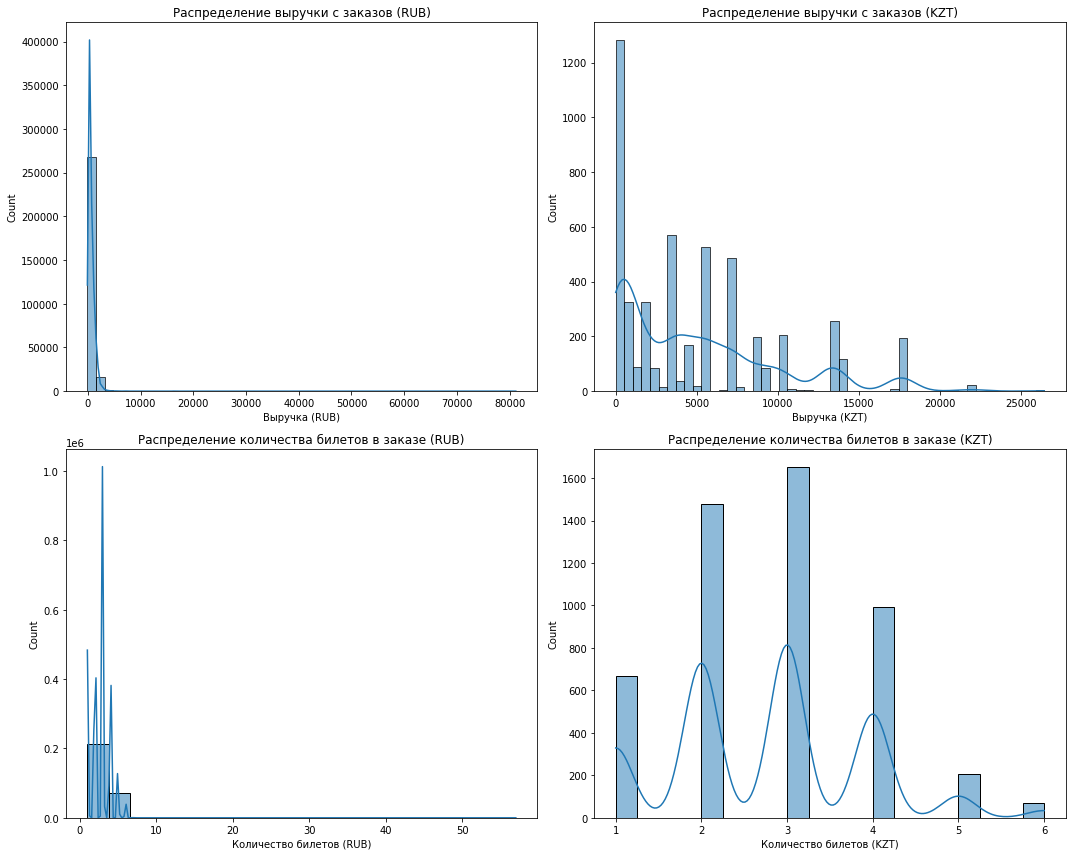

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Гистограмма revenue (RUB)
sns.histplot(rub_df['revenue'], ax=axes[0,0], kde=True, bins=50)
axes[0,0].set_title('Распределение выручки с заказов (RUB)')
axes[0,0].set_xlabel('Выручка (RUB)')

# Гистограмма revenue (KZT)
sns.histplot(kzt_df['revenue'], ax=axes[0,1], kde=True, bins=50)
axes[0,1].set_title('Распределение выручки с заказов (KZT)')
axes[0,1].set_xlabel('Выручка (KZT)')

# Гистограмма tickets_count (RUB)
sns.histplot(rub_df['tickets_count'], ax=axes[1,0], kde=True, bins=20)
axes[1,0].set_title('Распределение количества билетов в заказе (RUB)')
axes[1,0].set_xlabel('Количество билетов (RUB)')

# Гистограмма tickets_count (KZT)
sns.histplot(kzt_df['tickets_count'], ax=axes[1,1], kde=True, bins=20)
axes[1,1].set_title('Распределение количества билетов в заказе (KZT)')
axes[1,1].set_xlabel('Количество билетов (KZT)')

plt.tight_layout()
plt.show()

Выводы по гистограммам
1. Распределение выручки с заказов (RUB)
Форма распределения: сильно скошена вправо (асимметрична), с длинным «хвостом» в сторону высоких значений.
Пик распределения: сосредоточен в районе низких значений выручки (около 0–10000 руб.), что говорит о большом количестве недорогих заказов.
Выбросы: присутствуют экстремально высокие значения выручки (до 80 000 руб. и выше), которые формируют «хвост» графика и сильно влияют на среднее значение выручки.
2. Распределение выручки с заказов (KZT)
Форма распределения: также асимметрична, но менее экстремальная по сравнению с RUB.
Пик распределения: находится в диапазоне 0–5000 тенге, что указывает на преобладание недорогих заказов.
Распределение по диапазонам: после пика наблюдается постепенное снижение частоты с ростом выручки, с отдельными «всплесками» в диапазонах 5 000–10 000 тенге и выше.
Картина в целом схожа с RUB, но менее выражена: основная масса заказов — недорогие, с редкими более крупными транзакциями.
3. Распределение количества билетов в заказе (RUB)
Видны резкие падения после первых нескольких билетов.
Первый пик: около 1–2 билетов — одиночные или парные посещения, второй пик: около 3–5 билетов — семейные или групповые посещения.
Небольшое количество заказов с 10+ билетами — корпоративные брони или специальные мероприятия.
4. Распределение количества билетов в заказе (KZT)
3 билета — наиболее популярный размер заказа.
Распределение: частота плавно снижается с увеличением количества билетов, с небольшими «всплесками» на 2, 4 и 5 билетах.
Максимальные значения: до 6 билетов — практически отсутствуют заказы с большим количеством билетов.
Заказы в Казахстане более стандартизированы: большинство — небольшие группы (2–5 человек), крупных бронирований почти нет.

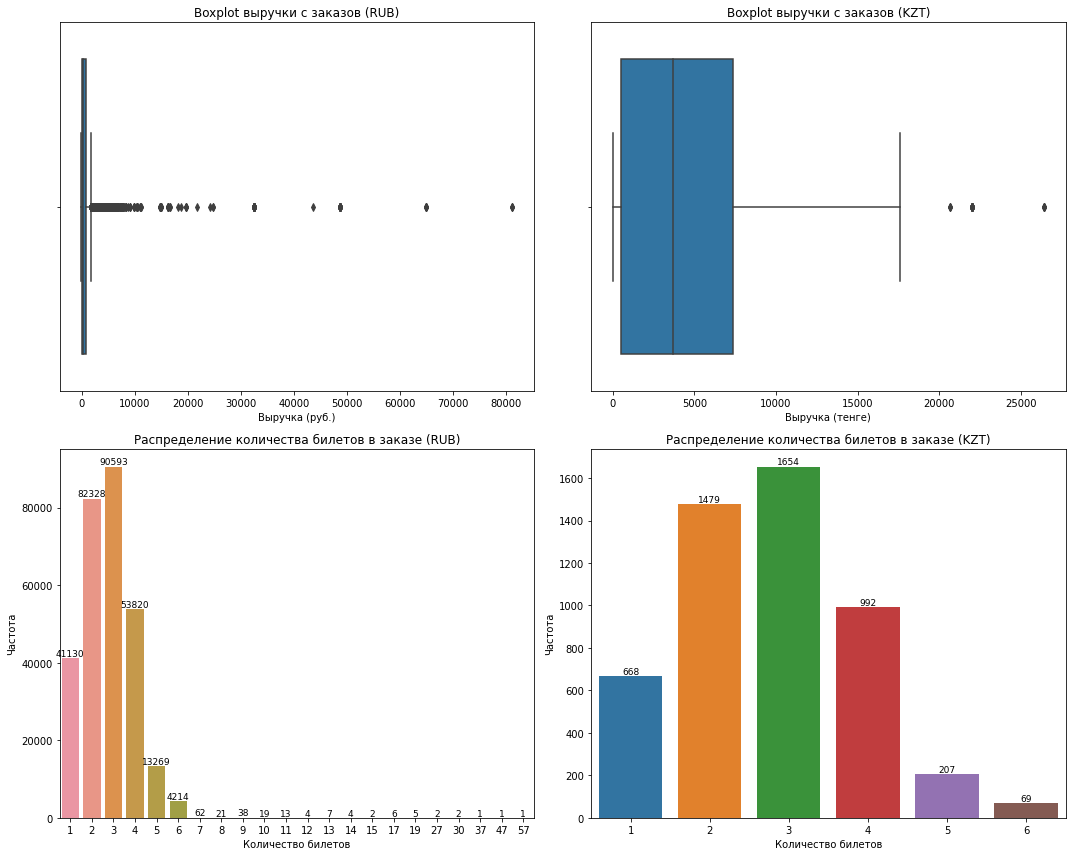

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Boxplot revenue (RUB) — оставляем, т. к. выручка непрерывна
sns.boxplot(x=rub_df['revenue'], ax=axes[0, 0])
axes[0, 0].set_title('Boxplot выручки с заказов (RUB)')
axes[0, 0].set_xlabel('Выручка (руб.)')

# Boxplot revenue (KZT) — оставляем
sns.boxplot(x=kzt_df['revenue'], ax=axes[0, 1])
axes[0, 1].set_title('Boxplot выручки с заказов (KZT)')
axes[0, 1].set_xlabel('Выручка (тенге)')

# Countplot tickets_count (RUB) — заменяем boxplot на countplot
sns.countplot(data=rub_df, x='tickets_count', ax=axes[1, 0])
axes[1, 0].set_title('Распределение количества билетов в заказе (RUB)')
axes[1, 0].set_xlabel('Количество билетов')
axes[1, 0].set_ylabel('Частота')

# Countplot tickets_count (KZT) — заменяем boxplot на countplot
sns.countplot(data=kzt_df, x='tickets_count', ax=axes[1, 1])
axes[1, 1].set_title('Распределение количества билетов в заказе (KZT)')
axes[1, 1].set_xlabel('Количество билетов')
axes[1, 1].set_ylabel('Частота')

# Добавляем подписи значений на countplot (опционально)
for ax in axes[1, :]:  # только нижние графики
    for p in ax.patches:
        if p.get_height() > 0:  # избегаем подписей для нулевых значений
            ax.annotate(f'{int(p.get_height())}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

1. Выручка с заказов (RUB)
Распределение: сильно асимметрично, с длинным «хвостом» из выбросов. Основная масса заказов сосредоточена в низком диапазоне выручки (ближе к началу оси X). Множество точек за пределами вертикальных «усов» boxplot, что указывает на наличие редких, но очень дорогих заказов (до 80 000 руб. и выше).
2. Выручка с заказов (KZT)
Распределение: более компактное по сравнению с RUB, меньше выбросов.
Медиана и квартили: коробка шире, что говорит о большем разбросе значений в «нормальном» диапазоне (примерно 0–10 000 тенге).
Несколько точек за пределами whiskers, но их количество и величина значительно меньше, чем в RUB.
Распределение более однородное — большинство заказов укладываются в средний ценовой диапазон. 
3. Количество билетов в заказе (RUB)
Высокая вариативность — от единичных билетов до крупных групп (до 50+ билетов).
Медиана: смещена влево, что говорит о преобладании небольших заказов (1–5 билетов).
Множество точек справа от коробки, указывающих на редкие, но крупные заказы (10+ билетов).
4. Количество билетов в заказе (KZT)
Распределение: более узкое и компактное, чем в RUB.
Медиана и квартили: коробка расположена в диапазоне 2–4 билетов, что является наиболее частым сценарием.
Выбросы: практически отсутствуют — все значения укладываются в узкий диапазон (до 6 билетов).

Ввиду значительных выбросов и аномалий, можно утверждать, что очистка по 99‑му процентилю и удаление явных ошибок позволят получить репрезентативную выборку для дальнейшего анализа

In [17]:
revenue_99_rub = rub_df['revenue'].quantile(0.99)
revenue_99_kzt = kzt_df['revenue'].quantile(0.99)

tickets_99_rub = rub_df['tickets_count'].quantile(0.99)
tickets_99_kzt = kzt_df['tickets_count'].quantile(0.99)

print(f"99‑й процентиль revenue (RUB): {revenue_99_rub:.2f}")
print(f"99‑й процентиль revenue (KZT): {revenue_99_kzt:.2f}")
print(f"99‑й процентиль tickets_count (RUB): {tickets_99_rub:.2f}")
print(f"99‑й процентиль tickets_count (KZT): {tickets_99_kzt:.2f}")

99‑й процентиль revenue (RUB): 2570.80
99‑й процентиль revenue (KZT): 17617.24
99‑й процентиль tickets_count (RUB): 6.00
99‑й процентиль tickets_count (KZT): 6.00


In [18]:
print("Отрицательные значения:")
print((afisha_df['revenue'] < 0).sum())
print((afisha_df['tickets_count'] < 0).sum())

print("Нулевые значения:")
print((afisha_df['revenue'] == 0).sum())
print((afisha_df['tickets_count'] == 0).sum())

Отрицательные значения:
381
0
Нулевые значения:
5526
0


In [19]:
# Фильтрация по 99‑му процентилю для RUB
rub_filtered = rub_df[
    (rub_df['revenue'] <= 2570.80) &
    (rub_df['tickets_count'] <= 6.00)
]

# Фильтрация по 99‑му процентилю для KZT
kzt_filtered = kzt_df[
    (kzt_df['revenue'] <= 17617.24) &
    (kzt_df['tickets_count'] <= 6.00)
]

# Объединение отфильтрованных данных
df_filtered = pd.concat([rub_filtered, kzt_filtered], ignore_index=True)

# Очистка от отрицательных и нулевых значений
df_cleaned = df_filtered[
    (df_filtered['revenue'] > 0) &
    (df_filtered['tickets_count'] >= 1)
]

# Вывод статистики после очистки
print("Статистика после фильтрации и очистки:")
print(df_cleaned.groupby('currency_code')[['revenue', 'tickets_count']].describe())

Статистика после фильтрации и очистки:
                revenue                                                   \
                  count         mean          std   min     25%      50%   
currency_code                                                              
kzt              5034.0  4899.501804  4742.493721  8.67  518.10  3698.83   
rub            276667.0   521.443700   500.497022  0.02  123.29   355.20   

                                 tickets_count                                \
                   75%       max         count      mean       std  min  25%   
currency_code                                                                  
kzt            7397.66  17617.24        5034.0  2.749106  1.101822  1.0  2.0   
rub             788.90   2570.80      276667.0  2.739246  1.137593  1.0  2.0   

                              
               50%  75%  max  
currency_code                 
kzt            3.0  3.0  6.0  
rub            3.0  3.0  6.0  


In [20]:
df_afisha = pd.concat([rub_filtered, kzt_filtered], axis=0).reset_index(drop=True)
df_afisha.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287602 entries, 0 to 287601
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                287602 non-null  int64  
 1   user_id                 287602 non-null  object 
 2   created_dt_msk          287602 non-null  object 
 3   created_ts_msk          287602 non-null  object 
 4   event_id                287602 non-null  int64  
 5   cinema_circuit          287602 non-null  object 
 6   age_limit               287602 non-null  int64  
 7   currency_code           287602 non-null  object 
 8   device_type_canonical   287602 non-null  object 
 9   revenue                 287602 non-null  float64
 10  service_name            287602 non-null  object 
 11  tickets_count           287602 non-null  int64  
 12  total                   287602 non-null  float64
 13  days_since_prev         265901 non-null  float64
 14  event_name          

Проверим на явные и неявные дубликаты

In [21]:
duplicates_full = df_afisha.duplicated().sum()
print(f"Количество явных полных дубликатов: {duplicates_full}")

Количество явных полных дубликатов: 0


In [22]:
# Определяем список столбцов для проверки дубликатов
colmn = [
    'user_id', 'created_dt_msk', 'created_ts_msk', 'event_id',
    'cinema_circuit', 'age_limit', 'currency_code', 'device_type_canonical',
    'service_name', 'tickets_count', 'total', 'event_name',
    'event_type_description', 'event_type_main', 'organizers',
    'region_name', 'city_name', 'venue_id', 'venue_name',
    'venue_address', 'days_since_prev'
]

# Получаем строки, которые являются дубликатами (без учёта order_id)
duplicate_mask = df_afisha.duplicated(subset=colmn, keep='first')
duplicates_data = df_afisha[duplicate_mask].copy()
print(f"Найдено неявных дубликатов: {len(duplicates_data)}")
print("\nПримеры дубликатов:")
print(duplicates_data[['user_id', 'order_id', 'created_dt_msk', 'event_id',
                      'revenue', 'tickets_count', 'currency_code']].head(10))

# Удаляем дубликаты из исходного датасета
df_afisha = df_afisha.drop_duplicates(subset=colmn, keep='first').reset_index(drop=True)

# Проверка результата
print(f"\nОсталось записей после удаления дубликатов: {len(df_afisha)}")

Найдено неявных дубликатов: 30

Примеры дубликатов:
                user_id  order_id created_dt_msk  event_id  revenue  \
11481   06eb7897f65b433   1123867     2024-08-13    183706    69.82   
55763   2564e3703075008    160893     2024-10-30    589005    11.23   
81673   3ee7dc2e115847f   3363798     2024-06-25    277504    59.19   
144295  7b525118ae656af   2323916     2024-10-28    588203    26.96   
149809  7eb4fc207ecc10f   5372831     2024-08-23    298035   126.84   
149814  7eb4fc207ecc10f   5373179     2024-08-23    298035   126.84   
150600  7eb4fc207ecc10f   3463819     2024-09-21    448579     2.54   
151780  7eb4fc207ecc10f   6657995     2024-10-26    418836   294.85   
169718  8d6c1ff89fac35f   6114564     2024-10-31    589624    41.83   
171495  8f95286aa5fd8d7   8248210     2024-06-20    244875    15.73   

        tickets_count currency_code  
11481               1           rub  
55763               2           rub  
81673               3           rub  
144295        

In [23]:
# Ключевые поля для идентификации бронирования
booking_keys = ['user_id', 'created_dt_msk', 'event_id',
              'revenue', 'tickets_count', 'currency_code', 'venue_id']

# Ищем дубликаты по критериям бронирования
booking_duplicates = df_afisha.duplicated(subset=booking_keys, keep=False)

# Выводим информацию о дубликатах
print(f"Дубликаты по бронированию (без order_id): {booking_duplicates.sum()} записей")

if booking_duplicates.sum() > 0:
    # Удаляем дубликаты, оставляя первую запись в каждой группе
    afisha_clean = df_afisha.drop_duplicates(subset=booking_keys, keep='first', ignore_index=True)
    print(f"После удаления дубликатов: {len(afisha_clean)} записей")
else:
    afisha_clean = df_afisha.copy()
    print("Дубликатов по бронированию не обнаружено")

# Финальная проверка — убеждаемся, что дубликатов больше нет
final_duplicates = afisha_clean.duplicated(subset=booking_keys).sum()
print(f"Осталось дубликатов после обработки: {final_duplicates}")

Дубликаты по бронированию (без order_id): 85489 записей
После удаления дубликатов: 234905 записей
Осталось дубликатов после обработки: 0


In [24]:
afisha_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234905 entries, 0 to 234904
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                234905 non-null  int64  
 1   user_id                 234905 non-null  object 
 2   created_dt_msk          234905 non-null  object 
 3   created_ts_msk          234905 non-null  object 
 4   event_id                234905 non-null  int64  
 5   cinema_circuit          234905 non-null  object 
 6   age_limit               234905 non-null  int64  
 7   currency_code           234905 non-null  object 
 8   device_type_canonical   234905 non-null  object 
 9   revenue                 234905 non-null  float64
 10  service_name            234905 non-null  object 
 11  tickets_count           234905 non-null  int64  
 12  total                   234905 non-null  float64
 13  days_since_prev         213204 non-null  float64
 14  event_name          

Преобразуем типы данных и при необходимости примем решение о снижении размерности некоторых типов

In [25]:
# Создаём независимую копию DataFrame, чтобы избежать SettingWithCopyWarning
afisha_clean = afisha_clean.copy()

# Преобразование дат в datetime
afisha_clean['created_dt_msk'] = pd.to_datetime(afisha_clean['created_dt_msk'])
afisha_clean['created_ts_msk'] = pd.to_datetime(afisha_clean['created_ts_msk'])

# Оптимизация числовых типов
float_columns = ['revenue', 'total', 'city_id', 'venue_id', 'days_since_prev']
for col in float_columns:
    afisha_clean[col] = pd.to_numeric(afisha_clean[col], downcast='float')
    print(f"Столбец {col} оптимизирован (float32)")

Столбец revenue оптимизирован (float32)
Столбец total оптимизирован (float32)
Столбец city_id оптимизирован (float32)
Столбец venue_id оптимизирован (float32)
Столбец days_since_prev оптимизирован (float32)


In [26]:
afisha_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234905 entries, 0 to 234904
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                234905 non-null  int64         
 1   user_id                 234905 non-null  object        
 2   created_dt_msk          234905 non-null  datetime64[ns]
 3   created_ts_msk          234905 non-null  datetime64[ns]
 4   event_id                234905 non-null  int64         
 5   cinema_circuit          234905 non-null  object        
 6   age_limit               234905 non-null  int64         
 7   currency_code           234905 non-null  object        
 8   device_type_canonical   234905 non-null  object        
 9   revenue                 234905 non-null  float32       
 10  service_name            234905 non-null  object        
 11  tickets_count           234905 non-null  int64         
 12  total                   234905

Создадим новые столбцы (для этого присоединим данные о курсе тенге к российскому рублю за 2024 год к данным о заказах и событиях)
* revenue_rub — выручка с заказа в rub. 
* one_ticket_revenue_rub — выручка с продажи одного билета на мероприятие.
* month — месяц оформления заказа.
* season — информация о сезонности, включая такие категории, как: 'лето', 'осень', 'зима', 'весна'.

In [27]:
# Приводим столбец data в tenge_df к типу datetime для корректного объединения
tenge_df['data'] = pd.to_datetime(tenge_df['data'])

# Выполняем слияние: указываем оба столбца для объединения
afisha = pd.merge(
    afisha_clean,
    tenge_df,
    left_on='created_dt_msk',  # столбец из afisha_clean для слияния
    right_on='data',       # столбец из tenge_df для слияния
    how='left'             # оставляем все записи из afisha_clean
)

# Проверка результата
afisha.info()
afisha.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 234905 entries, 0 to 234904
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                234905 non-null  int64         
 1   user_id                 234905 non-null  object        
 2   created_dt_msk          234905 non-null  datetime64[ns]
 3   created_ts_msk          234905 non-null  datetime64[ns]
 4   event_id                234905 non-null  int64         
 5   cinema_circuit          234905 non-null  object        
 6   age_limit               234905 non-null  int64         
 7   currency_code           234905 non-null  object        
 8   device_type_canonical   234905 non-null  object        
 9   revenue                 234905 non-null  float32       
 10  service_name            234905 non-null  object        
 11  tickets_count           234905 non-null  int64         
 12  total                   234905

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,data,nominal,curs,cdx
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.939941,...,Каменевский регион,Глиногорск,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-08-20,100,18.6972,kzt
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.450012,...,Каменевский регион,Глиногорск,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",2024-07-23,100,18.3419,kzt
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.569946,...,Каменевский регион,Глиногорск,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",2024-10-06,100,19.6475,kzt
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.490000,...,Североярская область,Озёрск,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",2024-07-13,100,18.5010,kzt
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.410034,...,Озернинский край,Родниковецк,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",2024-10-04,100,19.6648,kzt


In [28]:
# Создание revenue_rub — выручка в рублях
# Инициализируем колонку нулями
afisha['revenue_rub'] = 0.0

# Для записей в тенге конвертируем выручку: курс дан для 100 тенге, поэтому делим на 100
mask_tenge = afisha['currency_code'] == 'KZT'
if mask_tenge.sum() > 0:
    afisha.loc[mask_tenge, 'revenue_rub'] = (
        afisha.loc[mask_tenge, 'revenue'] *
        afisha.loc[mask_tenge, 'rate_100_tenge_to_rub'] / 100
    )

# Для остальных валют (предполагаем, что это уже рубли) просто копируем revenue
mask_other = afisha['currency_code'] != 'KZT'
afisha.loc[mask_other, 'revenue_rub'] = afisha.loc[mask_other, 'revenue']

# Заменяем возможные NaN в revenue_rub на 0 (если курс не найден)
afisha['revenue_rub'].fillna(0, inplace=True)

# 7. Создание one_ticket_revenue_rub — выручка с одного билета в рублях
# Используем np.divide для безопасного деления с обработкой деления на ноль
afisha['one_ticket_revenue_rub'] = np.divide(
    afisha['revenue_rub'],
    afisha['tickets_count'],
    out=np.zeros_like(afisha['revenue_rub']),
    where=afisha['tickets_count'] != 0
)
# Заменяем бесконечные значения на NaN
afisha['one_ticket_revenue_rub'].replace([np.inf, -np.inf], np.nan, inplace=True)


# Создание month — месяц оформления заказа
afisha['month'] = afisha['created_dt_msk'].dt.month

# Создание season — сезонность
def get_season(month):
    if month in [12, 1, 2]:
        return 'зима'
    elif month in [3, 4, 5]:
        return 'весна'
    elif month in [6, 7, 8]:
        return 'лето'
    else:  # 9, 10, 11
        return 'осень'

afisha['season'] = afisha['month'].apply(get_season)

afisha.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 234905 entries, 0 to 234904
Data columns (total 32 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                234905 non-null  int64         
 1   user_id                 234905 non-null  object        
 2   created_dt_msk          234905 non-null  datetime64[ns]
 3   created_ts_msk          234905 non-null  datetime64[ns]
 4   event_id                234905 non-null  int64         
 5   cinema_circuit          234905 non-null  object        
 6   age_limit               234905 non-null  int64         
 7   currency_code           234905 non-null  object        
 8   device_type_canonical   234905 non-null  object        
 9   revenue                 234905 non-null  float32       
 10  service_name            234905 non-null  object        
 11  tickets_count           234905 non-null  int64         
 12  total                   234905

In [29]:
# Проверим сколько удалено строк датасета
a, b = len(temp_1), len(afisha)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 290849 
 Осталось строк в датасете после обработки 234905 
 Удалено строк в датасете после обработки 55944 
 Процент потерь 19.23


**Полученные результаты после предобработки данных:**
1. В ходе объединения двух датасетов было обнаружено наличие в датасете events (~0.08%) и orders в столбце days_since_prev (21940 пропусков, что составляет ~7,5%).
Пропуски в events были удалены, т.к. их незначительное количество. Пропуски days_since_prev  в связаны скорее всего с тем, что для части заказов нет информации о предыдущем визите/событии (они оставлены без изменений).

2. Работа с категориальными значениями не выявила каких-либо аномалий.
3. Столбцы с датами created_dt_msk,created_ts_msk, data преобразованы в тип datetime.
4. Типы данных в таких столбцах как revenue, total, city_id, venue_id, days_since_prev были снижены.
5. Явные дубликаты обнаружены не были. Неявных дубликатов выявлено 30 шт., которые в последствии были удалены.
6. Были созданы дополнительные столбцы revenue_rub — выручка с заказа в rub, one_ticket_revenue_rub — выручка с продажи одного билета на мероприятие, month — месяц оформления заказа, season — информация о сезонности, включая такие категории, как: 'лето', 'осень', 'зима', 'весна'.

После всех произведенных действия осталось строк в датасете 234905, процент потерь составил 19,23%.

## Исследовательский анализ данных

In [30]:
# Агрегация заказов по месяцам
monthly_orders = afisha.groupby('month')['order_id'].count()

display(
    monthly_orders.to_frame('Количество заказов')
    .rename_axis('Месяц')
)

,Количество заказов
Месяц,
6,29097
7,34067
8,37345
9,56148
10,78248


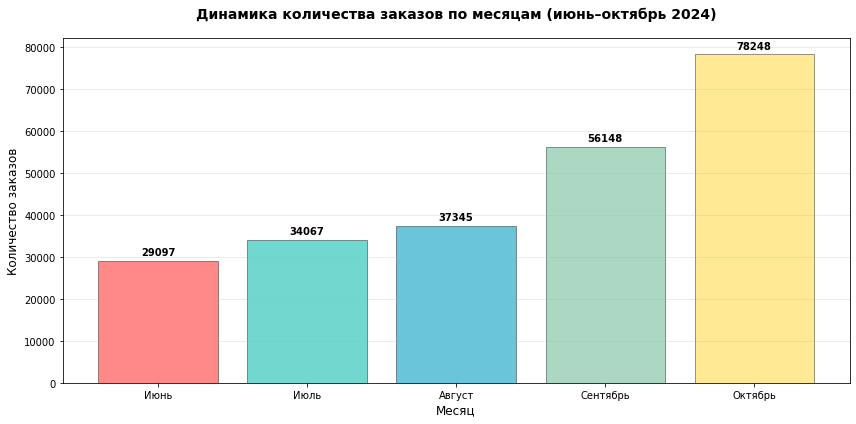

In [31]:
# Построение столбчатой диаграммы на основе серии monthly_orders
plt.figure(figsize=(12, 6))

# Создаём столбчатую диаграмму
bars = plt.bar(
    monthly_orders.index,
    monthly_orders.values,
    color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFE47A', '#DD866D'],
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5
)

# Настройка заголовка и подписей осей
plt.title(
    'Динамика количества заказов по месяцам (июнь–октябрь 2024)',
    fontsize=14,
    fontweight='bold',
    pad=20
)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)

# Определяем все месяцы, которые должны быть на графике
all_months = [6, 7, 8, 9, 10]
month_names = ['Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь']

# Устанавливаем позиции тиков и подписи
plt.xticks(ticks=all_months, labels=month_names)

# Добавляем сетку (только по оси Y для лучшей читаемости)
plt.grid(axis='y', alpha=0.3)

# Размещаем числовые значения над столбцами
max_value = max(monthly_orders.values) if len(monthly_orders) > 0 else 0
for month, count in monthly_orders.items():
    plt.text(
        month,
        count + max_value * 0.01,
        str(count),
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=10
    )

# Улучшаем внешний вид и показываем график
plt.tight_layout()
plt.show()

Общая тенденция — рост. На графике четко заметна позитивная динамика: количество заказов постепенно увеличивается с июня по ноябрь. Это свидетельствует о росте спроса в рассматриваемый период.

Начальный уровень (июнь). В июне количество заказов составило 29 097 — это минимальный показатель за период. Это может быть связано с сезонными факторами, стартовым уровнем активности или особенностями начала отчётного периода.
Постепенное увеличение (июль — сентябрь). В сентябре показатель достигает 56 148 заказов (+50% к августу). Этот этап демонстрирует устойчивый рост с ускорением в сентябре — возможно, за счёт маркетинговых акций, сезонного спроса или расширения клиентской базы.
Октябрь становится месяцем с максимальным количеством заказов — 78 248. Это на 39% больше, чем в сентябре. Такой скачок может быть обусловлен: предновогодними покупками (подготовка к праздникам); крупными промо-акциями; запуском новых продуктов/услуг;
Размах динамики. Разница между минимальным (июнь — 29 097) и максимальным (октябрь — 78 248) значениями составляет более 150%.

Посмотрим на распределение заказов в летний и осенний периоды.

In [32]:
# Определяем сезоны
summer_months = [6, 7, 8]
autumn_months = [9, 10, 11]

# Фильтруем данные
summer = afisha[afisha['month'].isin(summer_months)]
autumn = afisha[afisha['month'].isin(autumn_months)]

# Функция расчёта долей в %
def get_shares(data, col):
    return (data[col].value_counts(normalize=True) * 100).round(1)

colors = {'Лето': '#FF6B6B', 'Осень': '#4ECDC4'}
bar_width = 0.35

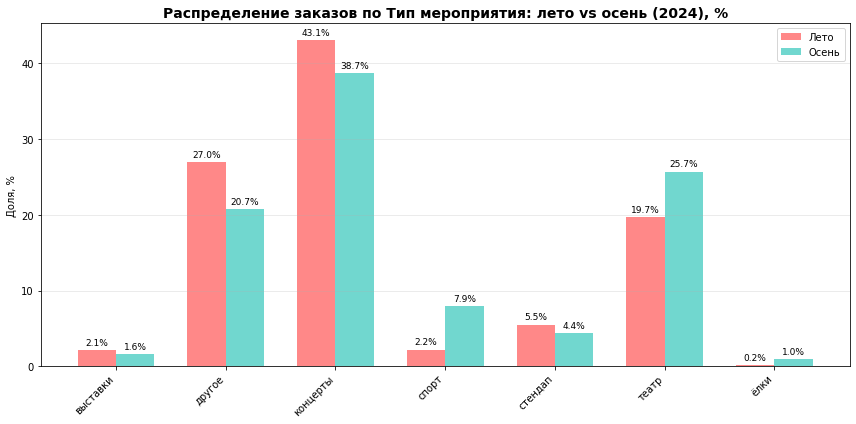

In [33]:
cat = 'event_type_main'
label = 'Тип мероприятия'

# Получаем доли
summer_share = get_shares(summer, cat)
autumn_share = get_shares(autumn, cat)


# Объединяем индексы, заполняем пропуски нулями
all_cats = summer_share.index.union(autumn_share.index)
summer_vals = summer_share.reindex(all_cats, fill_value=0)
autumn_vals = autumn_share.reindex(all_cats, fill_value=0)
x = np.arange(len(all_cats))


# Функция для добавления подписей над столбцами
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # показываем только ненулевые значения
            plt.annotate(f'{height:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # вертикальный отступ 3 пункта
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

# Создаём график
plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - bar_width/2, summer_vals, bar_width, label='Лето', color=colors['Лето'], alpha=0.8)
bars2 = plt.bar(x + bar_width/2, autumn_vals, bar_width, label='Осень', color=colors['Осень'], alpha=0.8)

# Добавляем подписи значений
add_value_labels(bars1)
add_value_labels(bars2)

# Настройки осей
plt.title(f'Распределение заказов по {label}: лето vs осень (2024), %', fontsize=14, fontweight='bold')
plt.xticks(x, all_cats, rotation=45, ha='right')
plt.ylabel('Доля, %')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

График показывает сравнение распределения заказов по типам мероприятий в летний и осенний периоды 2024 года (в процентах). Можно выделить следующие ключевые тенденции:

Концерты занимают абсолютное первенство летом с долей 43,1% — это существенно выше, чем любой другой тип мероприятий;
осенью доля концертов снижается до 38,7%, но по-прежнему остаётся самой высокой категорией.
Летом доминируют массовые мероприятия (концерты, стендапы), тогда как осенью наблюдается смещение интереса к другим форматам;
например, доля стендапов летом (5,5%) почти в 1,3 раза выше, чем осенью (4,4%).
Осенью заметно увеличивается доля заказов на театральные постановки (25,7%), в то время как летом этот показатель значительно ниже (19,7%). Это может быть связано с открытием театрального сезона.
Выставки имеют низкую долю заказов в оба периода (лето — 2,3%, осень — 1,6%), что может указывать на меньший спрос на этот тип мероприятий.
Наблюдаются сезонные сдвиги в предпочтениях — летом преобладают развлекательные массовые форматы, осенью — более «культурные».

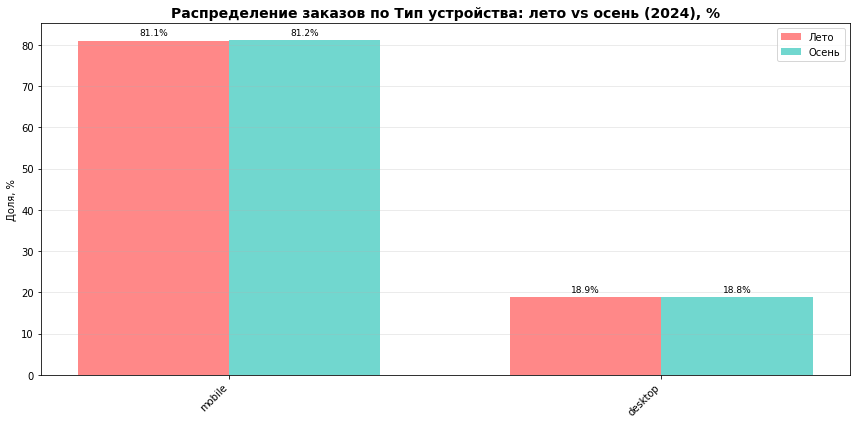

In [34]:
cat = 'device_type_canonical'
label = 'Тип устройства'

# Получаем доли
summer_share = get_shares(summer, cat)
autumn_share = get_shares(autumn, cat)

# Объединяем индексы, заполняем пропуски нулями
all_cats = summer_share.index.union(autumn_share.index)
summer_vals = summer_share.reindex(all_cats, fill_value=0)
autumn_vals = autumn_share.reindex(all_cats, fill_value=0)
x = np.arange(len(all_cats))

# Функция для добавления подписей над столбцами
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # показываем только ненулевые значения
            plt.annotate(f'{height:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # вертикальный отступ 3 пункта
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

# Создаём график
plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - bar_width/2, summer_vals, bar_width, label='Лето', color=colors['Лето'], alpha=0.8)
bars2 = plt.bar(x + bar_width/2, autumn_vals, bar_width, label='Осень', color=colors['Осень'], alpha=0.8)

# Добавляем подписи значений
add_value_labels(bars1)
add_value_labels(bars2)

# Настройки осей
plt.title(f'Распределение заказов по {label}: лето vs осень (2024), %', fontsize=14, fontweight='bold')
plt.xticks(x, all_cats, rotation=45, ha='right')
plt.ylabel('Доля, %')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

По графику мы видим, что основная часть заказов в оба сезона (лето и осень 2024 года) приходится на мобильные устройства:
* летом — 81,1%;
* осенью — 81,2%.
Это демонстрирует стабильно высокую зависимость пользователей от мобильных платформ при оформлении заказов, вне зависимости от времени года.
Доля заказов с десктопов существенно ниже:
* летом — 18,9%;
* осенью — 18,8%.
Это указывает на то, что десктопные устройства менее предпочтительны для совершения заказов по сравнению с мобильными.
Стабильность показателей между сезонами
Распределение заказов по типам устройств практически не изменилось с лета на осень.

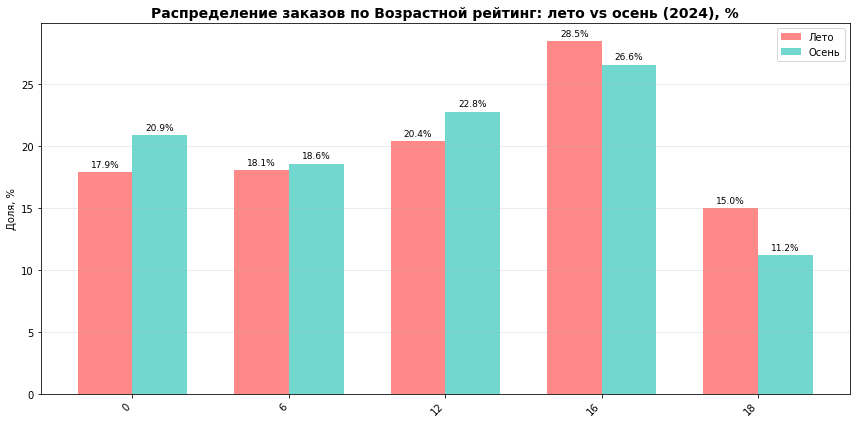

In [35]:
cat = 'age_limit'
label = 'Возрастной рейтинг'

# Получаем доли
summer_share = get_shares(summer, cat)
autumn_share = get_shares(autumn, cat)

# Объединяем индексы, заполняем пропуски нулями
all_cats = summer_share.index.union(autumn_share.index)
summer_vals = summer_share.reindex(all_cats, fill_value=0)
autumn_vals = autumn_share.reindex(all_cats, fill_value=0)
x = np.arange(len(all_cats))


def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # показываем только ненулевые значения
            plt.annotate(f'{height:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # вертикальный отступ 3 пункта
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

# Создаём график
plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - bar_width/2, summer_vals, bar_width, label='Лето', color=colors['Лето'], alpha=0.8)
bars2 = plt.bar(x + bar_width/2, autumn_vals, bar_width, label='Осень', color=colors['Осень'], alpha=0.8)

# Добавляем подписи значений
add_value_labels(bars1)
add_value_labels(bars2)

# Настройки осей
plt.title(f'Распределение заказов по {label}: лето vs осень (2024), %', fontsize=14, fontweight='bold')
plt.xticks(x, all_cats, rotation=45, ha='right')
plt.ylabel('Доля, %')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Наибольший спрос — на контент с рейтингом 16+.
Летом доля заказов с рейтингом «16+» составила 28,5%, осенью показатель немного снизился, но остаётся высоким — 26,6%.
Это указывает на стабильно высокий интерес взрослой аудитории (16+) к предлагаемым услугам/товарам в течение года.
Вторая по популярности категория — 12+
* Летом: 20,4%.
* Осенью: 22,8% (рост по сравнению с летом).
Рост доли в осенний период может быть связан с началом учебного года, семейными заказами или изменением потребительского поведения в холодное время года.
Рейтинг 6+ — устойчивая, но менее востребованная категория
* Лето: 18,1%.
* Осень: 18,6% (незначительный рост).
Доля остаётся стабильной, что говорит о постоянном спросе со стороны семей с детьми младшего школьного возраста.
Наименьший спрос — на контент с рейтингом 18+
Осеннее снижение может быть связано с уменьшением активности взрослой аудитории или сезонным смещением интересов.
Лето: доминирует контент для взрослых (16+) и универсальный (0+).
Осень: наблюдается сдвиг в сторону семейного контента (12+), при этом снижается доля «детской» (0+) и «строго взрослой» (18+) категорий.

Основная тенденция — устойчивый рост количества заказов
Анализ данных за период с июня по ноябрь демонстрирует чёткую позитивную динамику: количество заказов постепенно увеличивается. Ключевой показатель — рост более чем на 150% между минимальным (июнь, 29 097 заказов) и максимальным (октябрь, 78 248 заказов) значениями. Это свидетельствует о значительном увеличении спроса в рассматриваемый период.

Выделяются три ключевых этапа роста:
- Начальный уровень (июнь) — 29 097 заказов (минимальный показатель). Вероятно, обусловлен сезонными факторами или особенностями начала отчётного периода.
- Постепенное увеличение (июль — сентябрь) — устойчивый рост с ускорением в сентябре (56 148 заказов, +50% к августу). 
- Пик роста (октябрь) — максимальное количество заказов (78 248, +39% к сентябрю). Ключевые факторы

Сезонность существенно влияет на спрос. Контент для взрослых (16+) — ключевой сегмент в любое время года. Семейный сегмент (6+, 12+) демонстрирует стабильность с ростом осенью — перспективное направление для развития. Категории 0+ и 18+ чувствительны к сезонным изменениям — требуется гибкое ценообразованием.
Октябрь — пиковый месяц по количеству заказов. Успешные маркетинговые акции и запуск новых продуктов значительно стимулируют рост.

Теперь проверим осеннюю активность пользователей: проанализируем динамику изменений по дням и изучим недельную цикличность

In [36]:
# Фильтрация данных (осень 2024)
afisha_season = afisha[(afisha['season'] == 'осень')].copy()

# Сгруппируем отфильтрованные данные по дням и посчитаем метрики
afisha_three = afisha_season.groupby(afisha_season['created_dt_msk'].dt.date).agg(
    total_orders=('order_id', 'count'),
    dau=('user_id', 'nunique'),
    total_revenue=('revenue_rub', 'sum'),
    total_tickets=('tickets_count', 'sum')
).reset_index()

# Переименовываем столбцы
afisha_three.rename(
    columns={
        'created_dt_msk': 'Дата',
        'total_orders': 'Общее число заказов',
        'dau': 'Кол-во активных пользователей',
        'total_revenue': 'Общая выручка',
        'total_tickets': 'Общее кол-во билетов'
    },
    inplace=True
)

# Расчёт дополнительных метрик
afisha_three['Среднее число заказов на одного пользователя'] = (
    afisha_three['Общее число заказов'] / afisha_three['Кол-во активных пользователей']
)
afisha_three['Средняя стоимость одного билета'] = (
    afisha_three['Общая выручка'] / afisha_three['Общее кол-во билетов']
)

afisha_three = afisha_three[[
    'Дата',
    'Общее число заказов',
    'Кол-во активных пользователей',
    'Среднее число заказов на одного пользователя',
    'Общая выручка',  # добавляем обратно
    'Общее кол-во билетов',  # добавляем обратно
    'Средняя стоимость одного билета'
]]

afisha_three.head()

,Дата,Общее число заказов,Кол-во активных пользователей,Среднее число заказов на одного пользователя,Общая выручка,Общее кол-во билетов,Средняя стоимость одного билета
0,2024-09-01,1108,564,1.964539,600043.3125,3028,198.164898
1,2024-09-02,1173,574,2.043554,657849.0000,3129,210.242570
2,2024-09-03,2380,778,3.059126,824790.6250,6946,118.743252
3,2024-09-04,1450,685,2.116788,789130.4375,3979,198.323809
4,2024-09-05,1658,739,2.243572,945236.3125,4449,212.460398


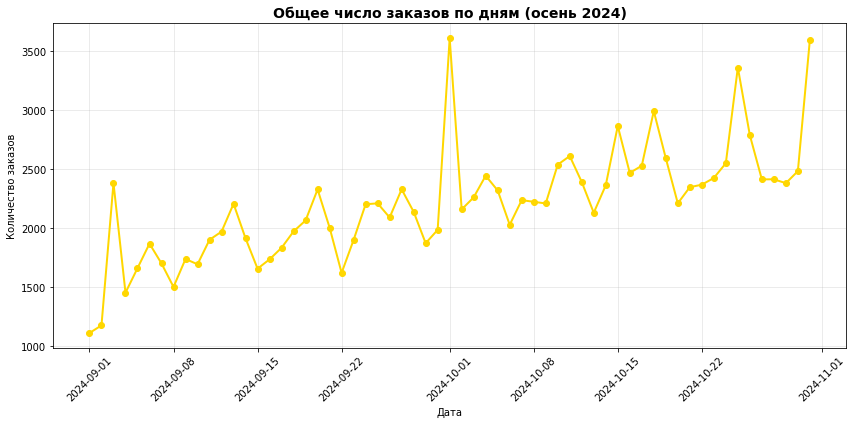

In [37]:
plt.figure(figsize=(12, 6))
plt.plot(afisha_three['Дата'], afisha_three['Общее число заказов'],
         marker='o', linewidth=2, color='#FFD700')
plt.title('Общее число заказов по дням (осень 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Количество заказов колеблется от ~1000 до 3500 в день.
Пиковые значения: несколько дней с резко повышенным спросом (до 3500 заказов), например, около 1 октября и в конце октября — начале ноября.
Низкие значения: в начале периода (около 1 сентября) наблюдается относительно низкий уровень заказов (около 1000).
Динамика: график демонстрирует волнообразную динамику — периоды роста чередуются с спадами.
Нет стабильной линейной тенденции: нет явного тренда на постоянный рост или снижение.

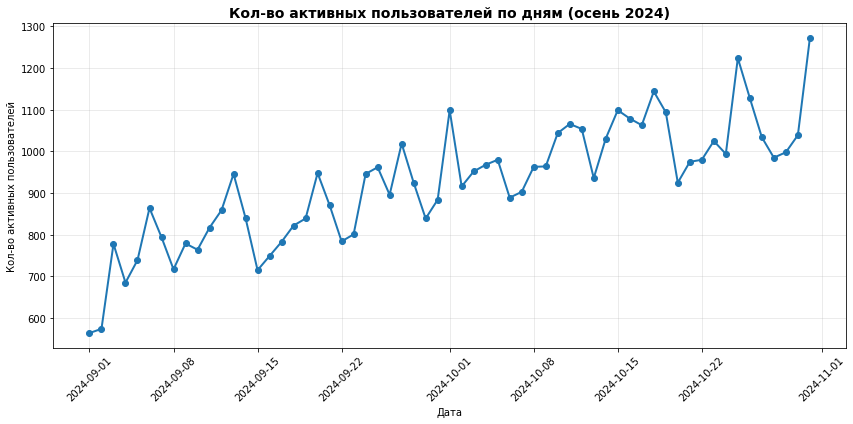

In [38]:
plt.figure(figsize=(12, 6))
plt.plot(afisha_three['Дата'], afisha_three['Кол-во активных пользователей'],
         marker='o', linewidth=2, color='#1f77b4')
plt.title('Кол-во активных пользователей по дням (осень 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Кол-во активных пользователей')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Минимальное количество пользователей: около 600 (начало периода, 1 сентября), максимальное количество пользователей: около 1300 (конец периода, 1 ноября).
Диапазон колебаний: от 600 до 1300 пользователей в день.
В начале периода (сентябрь) наблюдается относительно низкий уровень активности (около 600–800 пользователей).
С середины сентября начинается постепенный рост активности.
В октябре динамика становится волнообразной: периоды роста чередуются с небольшими спадами.
К концу периода (начало ноября) достигается пик активности — около 1300 пользователей.

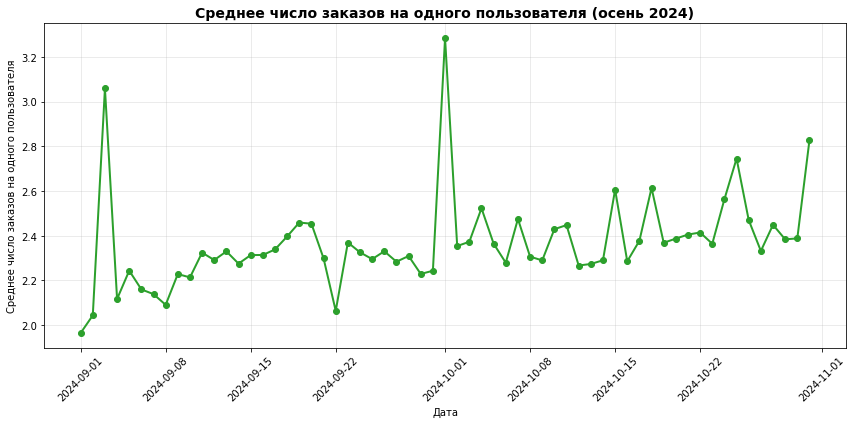

In [39]:
plt.figure(figsize=(12, 6))
plt.plot(afisha_three['Дата'], afisha_three['Общее число заказов'] / afisha_three['Кол-во активных пользователей'],
         marker='o', linewidth=2, color='#2ca02c')
plt.title('Среднее число заказов на одного пользователя (осень 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Среднее число заказов на одного пользователя')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

График демонстрирует волнообразную динамику с периодическими всплесками и спадами среднего числа заказов на одного пользователя. В целом уровень активности колеблется в диапазоне от 2 до 3,2 заказов на пользователя.
Ппервый значительный пик наблюдается в начале периода (около 2024-09-08) — среднее число заказов достигает ~3 заказов на пользователя, самый высокий пик зафиксирован около 2024-10-01 — максимальное значение ~3,2 заказа на пользователя;
в конце периода (около 2024-11-01) также заметен рост.
Нет чёткой линейной тенденции (ни роста, ни снижения) — динамика носит циклический характер.

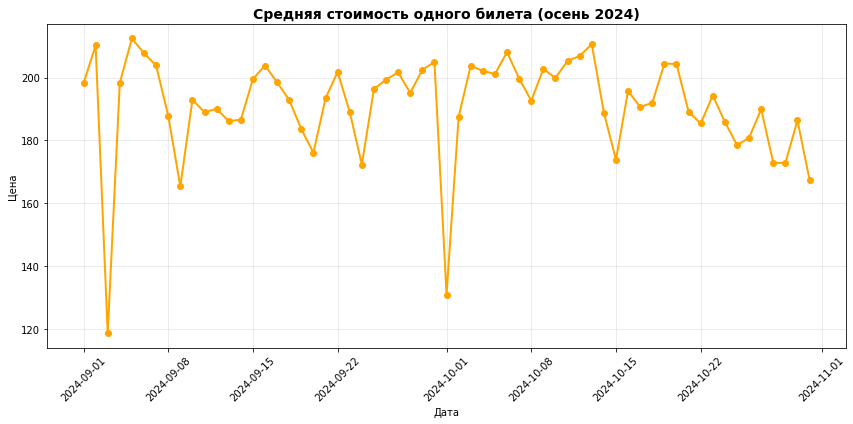

In [40]:
plt.figure(figsize=(12, 6))
plt.plot(afisha_three['Дата'],  afisha_three['Общая выручка'] / afisha_three['Общее кол-во билетов'],
         marker='o', linewidth=2, color='#FFA500')
plt.title('Средняя стоимость одного билета (осень 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Цена')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Средняя стоимость билета колеблется в диапазоне примерно от 120 до 200 руб. Наблюдаются значительные перепады в цене на протяжении периода.
График демонстрирует волнообразную динамику — частые подъёмы и спады стоимости;
Несколько дней с максимальной стоимостью около 200 руб. (например, в начале сентября и в середине октября);
Резкое снижение цены до 120 руб. отмечено примерно в середине сентября и в начале октября.

Средняя активность по дням недели (отсортировано):
day_name
Пн    1986.222222
Вт    2393.444444
Ср    2140.000000
Чт    2360.333333
Пт    2515.500000
Сб    2228.750000
Вс    1835.777778
Name: activity, dtype: float64

Будни: 2273.7 заказов/день
Выходные: 2020.7 заказов/день
Разница: -253.0 заказов

Доход:
Будни: 509 руб.
Выходные: 548 руб.


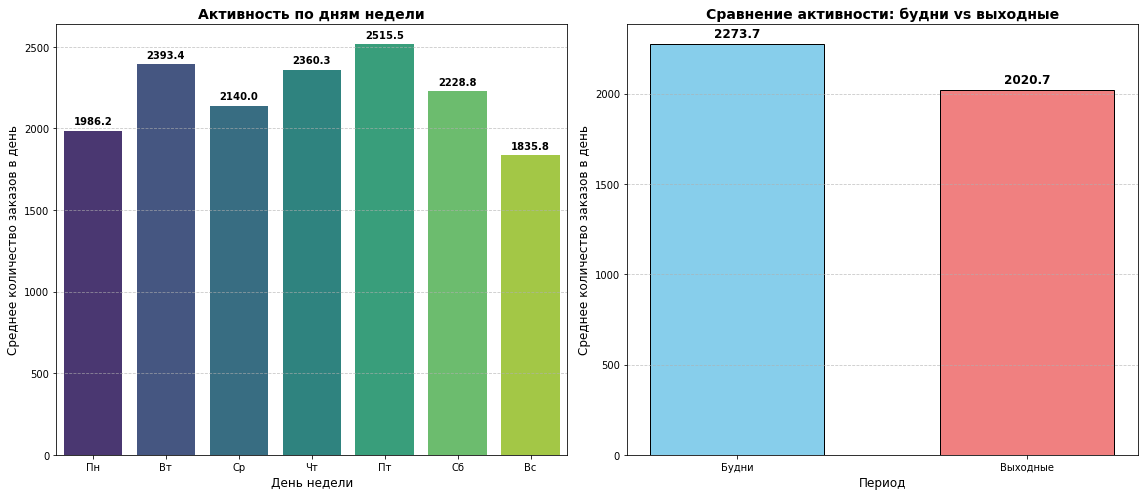

In [41]:
afisha_season['day_of_week'] = afisha_season['created_dt_msk'].dt.dayofweek  # 0=Пн, 6=Вс
afisha_season['is_weekend'] = afisha_season['day_of_week'].isin([5, 6])  # True = выходные
afisha_season['day_name'] = afisha_season['day_of_week'].map({0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'})


# Считаем активность (количество заказов в день)
daily_activity = afisha_season.groupby('created_dt_msk').size().reset_index(name='activity')

# Добавляем атрибуты дня недели к дневной активности
daily_activity['day_of_week'] = daily_activity['created_dt_msk'].dt.dayofweek
daily_activity['is_weekend'] = daily_activity['day_of_week'].isin([5, 6])
daily_activity['day_name'] = daily_activity['day_of_week'].map({0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'})


# Средняя активность по дням недели — с правильной сортировкой
ordered_days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
weekly_avg = daily_activity.groupby('day_name')['activity'].mean()
weekly_avg_sorted = weekly_avg.reindex(ordered_days)  # Сортируем по порядку дней недели
print("Средняя активность по дням недели (отсортировано):")
print(weekly_avg_sorted)

# Средняя активность: будни vs выходные
weekend_avg = daily_activity[daily_activity['is_weekend']]['activity'].mean()
weekday_avg = daily_activity[~daily_activity['is_weekend']]['activity'].mean()
print(f"\nБудни: {weekday_avg:.1f} заказов/день")
print(f"Выходные: {weekend_avg:.1f} заказов/день")
print(f"Разница: {weekend_avg - weekday_avg:.1f} заказов")

# Средний доход в будни и выходные
revenue_weekend = afisha_season[afisha_season['is_weekend']]['revenue_rub'].mean()
revenue_weekday = afisha_season[~afisha_season['is_weekend']]['revenue_rub'].mean()
print(f"\nДоход:")
print(f"Будни: {revenue_weekday:.0f} руб.")
print(f"Выходные: {revenue_weekend:.0f} руб.")

plt.figure(figsize=(16, 7))

# График 1: Активность по дням недели (отсортированный)
plt.subplot(1, 2, 1)
ax1 = sns.barplot(x=weekly_avg_sorted.index, y=weekly_avg_sorted.values, palette='viridis')
plt.title('Активность по дням недели', fontsize=14, fontweight='bold')
plt.ylabel('Среднее количество заказов в день', fontsize=12)
plt.xlabel('День недели', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Добавляем значения на столбцы
max_value = weekly_avg_sorted.max() if len(weekly_avg_sorted) > 0 else 0
for i, v in enumerate(weekly_avg_sorted.values):
    ax1.text(i, v + max_value * 0.01, f'{v:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=10)


# График 2: будни vs выходные
plt.subplot(1, 2, 2)
labels = ['Будни', 'Выходные']
values = [weekday_avg, weekend_avg]
ax2 = plt.bar(labels, values, color=['skyblue', 'lightcoral'], edgecolor='black', width=0.6)
plt.title('Сравнение активности: будни vs выходные', fontsize=14, fontweight='bold')
plt.ylabel('Среднее количество заказов в день', fontsize=12)
plt.xlabel('Период', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)


# Добавляем значения на столбцы второго графика
max_val = max(values) if len(values) > 0 else 0
for i, v in enumerate(values):
    plt.text(i, v + max_val * 0.01, f'{v:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

1. Активность по дням недели (среднее количество заказов в день):
Максимальная активность наблюдается в пятницу (2515.5 заказов), вероятно, связанный с подготовкой к выходным или специфическими событиями/спросом в этот день.
Второй по активности день — вторник (2393.4 заказа). Минимальная активность зафиксирована в воскресенье (1835.8 заказов) — традиционный «спокойный» день, когда спрос ниже из-за выходных.

2. Сравнение будней и выходных:
Средняя активность в будни: 2273.7 заказов/день, средняя активность в выходные: 2020.7 заказов/день.
Разница: –253.0 заказа (в выходные активность ниже, чем в будни).
Рабочая неделя демонстрирует более высокий спрос, чем выходные. Это может быть связано с: рабочим графиком клиентов (в будни больше времени/возможности для заказов); корпоративным спросом (будни — период активности бизнес-клиентов).

3. Анализ дохода:
Доход в будни: 509 руб, доход в выходные: 548 руб.
Несмотря на меньшую активность в выходные, средний доход чуть выше, чем в будни. 
4. Ключевые тенденции:
Пятница — ключевой день для максимизации продаж/активности.
Воскресенье — требует специальных мер для стимулирования спроса (акции, промо).

Теперь изучим как события распределены по регионам и партнёрам. Это позволит выделить ключевые регионы и партнёров, которые вносят наибольший вклад в выручку.

In [42]:
unique_events_by_region = afisha.groupby('region_name')['event_id'].nunique().sort_values(ascending=False)
result_df = unique_events_by_region.reset_index()
result_df.columns = ['Наименование региона', 'Количество мероприятий']
display(result_df)

,Наименование региона,Количество мероприятий
0,Каменевский регион,5933
1,Североярская область,3797
2,Широковская область,1232
3,Светополянский округ,1075
4,Речиновская область,702
...,...,...
76,Теплоозёрский округ,2
77,Сосноводолинская область,2
78,Лесноярский край,2
79,Светолесский край,2


In [43]:
# Агрегация данных по регионам
region_stats = afisha.groupby('region_name').agg(
    уникальное_количество_мероприятий=('event_id', 'nunique'),  # Уникальные мероприятия
    общее_число_заказов=('order_id', 'count'),                 # Общее число заказов
    суммарная_выручка=('revenue', 'sum')                       # Суммарная выручка
).reset_index().sort_values('общее_число_заказов', ascending=False)

# Вычисляем общие итоги (для расчёта долей)
total_events = afisha['event_id'].nunique()
total_orders = afisha['order_id'].count()
total_revenue = afisha['revenue'].sum()

# Рассчитываем доли от общего количества
region_stats['доля_мероприятий'] = region_stats['уникальное_количество_мероприятий'] / total_events * 100
region_stats['доля_заказов'] = region_stats['общее_число_заказов'] / total_orders * 100
region_stats['доля_выручки'] = region_stats['суммарная_выручка'] / total_revenue * 100

# Форматируем числа (добавляем разделители тысяч, округляем проценты)
pd.options.display.float_format = '{:,.2f}'.format

region_stats_formatted = region_stats.copy()

region_stats_formatted['уникальное_количество_мероприятий'] = region_stats_formatted['уникальное_количество_мероприятий'].apply(
    lambda x: f"{x:,.0f}".replace(",", " "))

region_stats_formatted['общее_число_заказов'] = region_stats_formatted['общее_число_заказов'].apply(
    lambda x: f"{x:,.0f}".replace(",", " "))

region_stats_formatted['суммарная_выручка'] = region_stats_formatted['суммарная_выручка'].apply(
    lambda x: f"{x:,.0f}".replace(",", " ") + " руб.")

region_stats_formatted['доля_мероприятий'] = region_stats_formatted['доля_мероприятий'].apply(
    lambda x: f"{x:.1f}%")

region_stats_formatted['доля_заказов'] = region_stats_formatted['доля_заказов'].apply(
    lambda x: f"{x:.1f}%")

region_stats_formatted['доля_выручки'] = region_stats_formatted['доля_выручки'].apply(
    lambda x: f"{x:.1f}%")

# Переименовываем индекс (первую колонку)
region_stats_formatted = region_stats_formatted.rename_axis('Наименование региона')

display(region_stats_formatted)

# Выводим общие итоги в виде строки
print(f"\nОБЩИЕ ИТОГИ:")
print(f"Уникальных мероприятий: {total_events:,}")
print(f"Общего числа заказов: {total_orders:,}")
print(f"Суммарной выручки: {total_revenue:,.0f} руб.")

,region_name,уникальное_количество_мероприятий,общее_число_заказов,суммарная_выручка,доля_мероприятий,доля_заказов,доля_выручки
Наименование региона,,,,,,,
23,Каменевский регион,5 933,74 438,47 315 472 руб.,26.5%,31.7%,34.5%
60,Североярская область,3 797,37 439,18 703 012 руб.,17.0%,15.9%,13.7%
77,Широковская область,1 232,13 649,7 257 466 руб.,5.5%,5.8%,5.3%
45,Озернинский край,349,8 599,7 908 142 руб.,1.6%,3.7%,5.8%
42,Медовская область,504,6 808,1 938 677 руб.,2.3%,2.9%,1.4%
...,...,...,...,...,...,...,...
32,Крутоводский регион,7,15,4 742 руб.,0.0%,0.0%,0.0%
80,Яснопольский округ,5,14,791 руб.,0.0%,0.0%,0.0%
5,Верхозёрский край,2,9,1 746 руб.,0.0%,0.0%,0.0%



ОБЩИЕ ИТОГИ:
Уникальных мероприятий: 22,350
Общего числа заказов: 234,905
Суммарной выручки: 136,985,824 руб.


Лидер по количеству мероприятий и заказов — Каменевский регион 5 933 уникальными мероприятиями (26,5% от общего числа), объём заказов — 74 438 (31,7% от общего числа). Это ключевой регион с точки зрения масштаба и доходности.

Регионы с умеренным вкладом:
- Широковская область (5,5% мероприятий, 5,8% заказов, 5,3% выручки) — стабильный регион с умеренной активностью.
- Озернинский край (1,6% мероприятий, 3,7% заказов, 5,8% выручки) — относительно низкий объём мероприятий, но неплохая выручка.
- Светополянский округ (4,8% мероприятий, 2,7% заказов, 1,8% выручки) — хороший потенциал по числу мероприятий, но ниже среднего по заказам и выручке.

Регионы с низкой долей в общих показателях:
- Малиновоярский округ (0,7% мероприятий, 2,3% заказов, 3,1% выручки) — небольшой объём мероприятий, но относительно высокая доля в выручке, что может указывать на высокую стоимость билетов или премиальность событий.
- Серебринская область (2,4% мероприятий, 2% заказов, 1,3% выручки) — низкие показатели по всем направлениям, требует анализа причин низкой конверсии.


Значительная часть мероприятий, заказов и выручки сконцентрирована в нескольких крупных регионах (Каменевский, Североярская область).
Разрыв между количеством мероприятий и выручкой: например, в Светополянском округе много мероприятий, но низкая выручка — возможно, из-за низкой стоимости билетов или слабого спроса.
Дисбаланс между заказами и выручкой: в некоторых регионах (например, Озернинский край) количество заказов выше, чем доля в выручке, что может говорить о низкой средней стоимости заказа.

In [44]:
# Агрегация данных по билетным партнёрам (столбец service_name)
partner_stats = afisha.groupby('service_name').agg(
    уникальное_количество_мероприятий=('event_id', 'nunique'),  # Уникальные мероприятия
    общее_число_заказов=('order_id', 'count'),                 # Обработанные заказы
    суммарная_выручка=('revenue', 'sum')                       # Суммарная выручка
).sort_values('общее_число_заказов', ascending=False)  # Сортировка по числу заказов (от большего к меньшему)

# Вычисляем общие итоги (для расчёта долей)
total_events = afisha['event_id'].nunique()
total_orders = afisha['order_id'].count()
total_revenue = afisha['revenue'].sum()

# Рассчитываем доли от общего количества
partner_stats['доля_мероприятий'] = partner_stats['уникальное_количество_мероприятий'] / total_events * 100
partner_stats['доля_заказов'] = partner_stats['общее_число_заказов'] / total_orders * 100
partner_stats['доля_выручки'] = partner_stats['суммарная_выручка'] / total_revenue * 100

# Форматируем числа
pd.options.display.float_format = '{:,.2f}'.format

partner_stats_formatted = partner_stats.copy()

# Форматирование колонок
partner_stats_formatted['уникальное_количество_мероприятий'] = partner_stats_formatted['уникальное_количество_мероприятий'].apply(
    lambda x: f"{x:,.0f}".replace(",", " "))

partner_stats_formatted['общее_число_заказов'] = partner_stats_formatted['общее_число_заказов'].apply(
    lambda x: f"{x:,.0f}".replace(",", " "))

partner_stats_formatted['суммарная_выручка'] = partner_stats_formatted['суммарная_выручка'].apply(
    lambda x: f"{x:,.0f}".replace(",", " ") + " руб.")

partner_stats_formatted['доля_мероприятий'] = partner_stats_formatted['доля_мероприятий'].apply(
    lambda x: f"{x:.1f}%")

partner_stats_formatted['доля_заказов'] = partner_stats_formatted['доля_заказов'].apply(
    lambda x: f"{x:.1f}%")

partner_stats_formatted['доля_выручки'] = partner_stats_formatted['доля_выручки'].apply(
    lambda x: f"{x:.1f}%")

# Переименовываем индекс
partner_stats_formatted = partner_stats_formatted.rename_axis('Билетный партнёр (service_name)')

display(partner_stats_formatted.head(10))

# Выводим общие итоги
print(f"\nОБЩИЕ ИТОГИ:")
print(f"Уникальных мероприятий: {total_events:,}")
print(f"Общего числа заказов: {total_orders:,}")
print(f"Суммарной выручки: {total_revenue:,.0f} руб.")

,уникальное_количество_мероприятий,общее_число_заказов,суммарная_выручка,доля_мероприятий,доля_заказов,доля_выручки
Билетный партнёр (service_name),,,,,,
Билеты без проблем,4 240,52 450,22 828 906 руб.,19.0%,22.3%,16.7%
Лови билет!,4 866,33 531,13 534 234 руб.,21.8%,14.3%,9.9%
Билеты в руки,3 527,29 162,10 625 715 руб.,15.8%,12.4%,7.8%
Мой билет,1 297,27 996,28 172 400 руб.,5.8%,11.9%,20.6%
Облачко,2 335,23 036,16 091 965 руб.,10.4%,9.8%,11.7%
Лучшие билеты,1 762,14 519,2 248 428 руб.,7.9%,6.2%,1.6%
Весь в билетах,855,14 008,14 113 451 руб.,3.8%,6.0%,10.3%
Прачечная,1 025,7 839,3 656 305 руб.,4.6%,3.3%,2.7%
Край билетов,252,5 038,5 310 910 руб.,1.1%,2.1%,3.9%



ОБЩИЕ ИТОГИ:
Уникальных мероприятий: 22,350
Общего числа заказов: 234,905
Суммарной выручки: 136,985,824 руб.


Лидеры по количеству мероприятий:
- «Лови билет!» — абсолютный лидер с 4 866 мероприятиями (21,8% от общего числа), демонстрирует самую широкую программу.
- «Билеты без проблем» — 4 240 мероприятий (19%), занимает второе место по масштабу присутствия.
- «Билеты в руки» — 3 527 мероприятий (15,8%), третий по объёму партнёр.

Лидеры по количеству заказов:
- «Билеты без проблем» — 52 450 заказов (22,3% от общего числа), безусловный лидер по конверсии в продажи.
- «Мой билет» — 27 996 заказов (11,9%), показывает высокую активность несмотря на меньшее количество мероприятий (1 297).
- «Лови билет!» — 33 531 заказ (14,3%), хорошо сочетает широту ассортимента и объём продаж.

Лидеры по выручке:
- «Мой билет» — 28 172 400 руб. (20,6% от общей выручки), самый прибыльный партнёр, несмотря на относительно небольшое количество мероприятий и заказов. Вероятно, работает с премиальными событиями или высокими ценами.
- «Билеты без проблем» — 22 828 906 руб. (16,7%), сочетает объём и доходность.
- «Облачко» — 16 091 965 руб. (11,7%), демонстрирует сбалансированный результат.

«Облачко» и «Билеты в руки» демонстрируют сбалансированный результат по всем трём показателям (количество мероприятий, заказов, выручка). «Прачечная» показывает умеренные результаты по всем направлениям (7 839 заказов, 3 656 305 руб. выручки), без явного лидерства в отдельных показателях.

Неравномерность распределения: топ-3 партнёров по выручке («Мой билет», «Билеты без проблем», «Облачко») контролируют более 49% всей выручки.
Разрыв между количеством мероприятий и выручкой: некоторые партнёры (например, «Лучшие билеты») имеют много мероприятий, но низкую долю в выручке — это сигнал для анализа ценовой политики и конверсии.
Важность средней стоимости билета: партнёры с небольшим количеством мероприятий («Весь в билетах», «Край билетов») могут быть более прибыльными за счёт высоких цен.

Общие выводы
1. Рост спроса: зафиксировано увеличение количества заказов более чем на 150% с июня (29 097 заказов) по октябрь (78 248 заказов). Выделены три этапа роста: стартовый уровень в июне, постепенное увеличение (июль — сентябрь) и пик в октябре (+39% к сентябрю).

2. Сезонные сдвиги в предпочтениях:
Лето: преобладание массовых мероприятий (концерты — 43,1%, стендапы — 5,5%).
Осень: рост интереса к «культурным» форматам (театральные постановки — 25,7%), снижение доли концертов (38,7%) и стендапов (4,4%).

3. Доминирование мобильных платформ: около 81% заказов оформляется с мобильных устройств (стабильно летом и осенью), десктопные устройства менее востребованы (около 18%).

4. Лидерство контента 16+: стабильно высокая доля заказов (28,5% летом, 26,6% осенью). Рост интереса к семейному контенту (12+) осенью (22,8%).

5. Региональные дисбалансы:

Лидер: Каменевский регион (26,5% мероприятий, 31,7% заказов) — ключевой с точки зрения масштаба и доходности.
Регионы с умеренной активностью: Широковская область, Озернинский край, Светополянский округ — различаются по соотношению мероприятий, заказов и выручки.
Низкие показатели: Серебринская область (по всем направлениям), Малиновоярский округ (небольшое число мероприятий, но относительно высокая доля в выручке).

6. Лидеры среди билетных партнёров:

По числу мероприятий: «Лови билет!» (21,8%), «Билеты без проблем» (19%), «Билеты в руки» (15,8%).
По заказам: «Билеты без проблем» (22,3%), «Мой билет» (11,9%), «Лови билет!» (14,3%).
По выручке: «Мой билет» (20,6%), «Билеты без проблем» (16,7%), «Облачко» (11,7%).

7. Ценовая динамика: средняя стоимость билета — 120–200 руб. с частыми перепадами.

8. Активность по дням недели:

Максимальная: пятница (2 515,5 заказов) — ключевой день для продаж.
Минимальная: воскресенье (1 835,8 заказов) — требуется стимулирование спроса.
Будни vs выходные: выше активность в будни (2 273,7 заказов/день), но выше средний доход в выходные (548 руб. против 509 руб. в будни).

9. Неравномерность распределения выручки: топ-3 партнёров по выручке контролируют почти 50% общей прибыли, что требует анализа менее эффективных партнёров и оптимизации ценовой политики.

## Статистический анализ данных

Проверим две гипотезы, которые предполагают большую активность пользователей мобильных устройств:
* Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.
* Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

**Проверим первую гипотезу:**

Нулевая гипотеза (H₀): Среднее количество заказов на одного пользователя у пользователей мобильных устройств не выше, чем у пользователей стационарных устройств.

Альтернативная гипотеза (H₁): Среднее количество заказов на одного пользователя у пользователей мобильных устройств строго выше, чем у пользователей стационарных устройст.

In [45]:
# Фильтрация данных за осенний период (сентябрь–ноябрь)
autumn_data = afisha[afisha['month'].isin([9, 10, 11])]

# Проверка на пересечения пользователей между мобильными и стационарными устройствами
users_mobile = set(autumn_data[autumn_data['device_type_canonical'] == 'mobile']['user_id'])
users_desktop = set(autumn_data[autumn_data['device_type_canonical'] == 'desktop']['user_id'])
overlapping_users = users_mobile & users_desktop

print(f"Всего уникальных пользователей (мобильные): {len(users_mobile)}")
print(f"Всего уникальных пользователей (стационарные): {len(users_desktop)}")
print(f"Количество пользователей, использующих оба типа устройств: {len(overlapping_users)}")

if len(overlapping_users) > 0:
    print("\nЕсть пользователи, использующие оба типа устройств")
    print(f"Это {len(overlapping_users) / len(users_mobile) * 100:.1f}% от мобильных пользователей")
    print(f"и {len(overlapping_users) / len(users_desktop) * 100:.1f}% от стационарных пользователей")
else:
    print("\nПересекающихся пользователей не обнаружено.")

# Разделение на выборки по типу устройства с агрегацией по пользователям
mobile_orders = autumn_data[autumn_data['device_type_canonical'] == 'mobile'].groupby('user_id').size()
desktop_orders = autumn_data[autumn_data['device_type_canonical'] == 'desktop'].groupby('user_id').size()


# Описательные статистики
stats_mobile = mobile_orders.describe()
stats_desktop = desktop_orders.describe()

comparison = pd.DataFrame({
    'Мобильные устройства': stats_mobile,
    'Стационарные устройства': stats_desktop
})
print("\nОписательные статистики:")
print(comparison)

# Средние значения количества заказов на пользователя
mean_mobile = mobile_orders.mean()
mean_desktop = desktop_orders.mean()
print(f"\nСреднее количество заказов на пользователя:")
print(f"Мобильные устройства: {mean_mobile:.2f}")
print(f"Стационарные устройства: {mean_desktop:.2f}")

# Дополнительная статистика по пересекающимся пользователям (если они есть)
if len(overlapping_users) > 0:
    print(f"\nДополнительная статистика по пересекающимся пользователям ({len(overlapping_users)} чел.):")
    
    # Данные по пересекающимся пользователям
    overlapping_data = autumn_data[autumn_data['user_id'].isin(overlapping_users)]
    
    overlap_mobile = overlapping_data[overlapping_data['device_type_canonical'] == 'mobile'].groupby('user_id').size()
    overlap_desktop = overlapping_data[overlapping_data['device_type_canonical'] == 'desktop'].groupby('user_id').size()
    
    if len(overlap_mobile) > 0:
        print(f"Среднее количество заказов с мобильных (среди пересекающихся): {overlap_mobile.mean():.2f}")
    if len(overlap_desktop) > 0:
        print(f"Среднее количество заказов со стационарных (среди пересекающихся): {overlap_desktop.mean():.2f}")

Всего уникальных пользователей (мобильные): 14174
Всего уникальных пользователей (стационарные): 4842
Количество пользователей, использующих оба типа устройств: 3211

Есть пользователи, использующие оба типа устройств
Это 22.7% от мобильных пользователей
и 66.3% от стационарных пользователей

Описательные статистики:
       Мобильные устройства  Стационарные устройства
count             14,174.00                 4,842.00
mean                   7.70                     5.22
std                   56.05                    26.62
min                    1.00                     1.00
25%                    1.00                     1.00
50%                    2.00                     2.00
75%                    4.00                     3.00
max                3,699.00                 1,184.00

Среднее количество заказов на пользователя:
Мобильные устройства: 7.70
Стационарные устройства: 5.22

Дополнительная статистика по пересекающимся пользователям (3211 чел.):
Среднее количество заказов с м

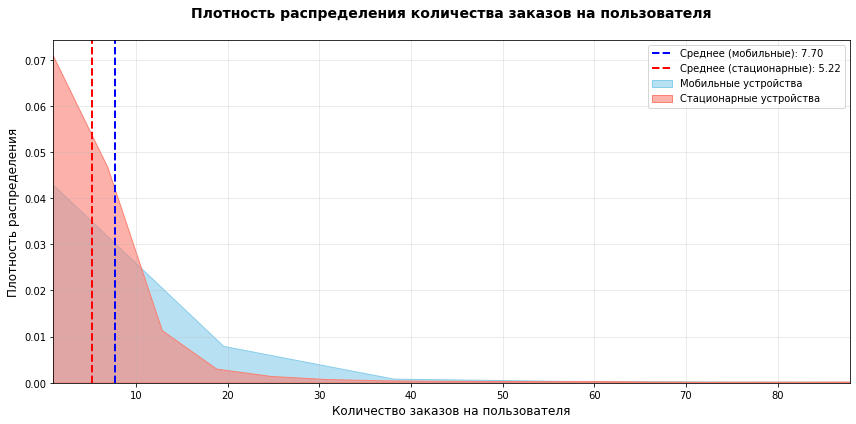

In [46]:
lower_bound = np.percentile(np.concatenate([mobile_orders, desktop_orders]), 1)
upper_bound = np.percentile(np.concatenate([mobile_orders, desktop_orders]), 99)

plt.figure(figsize=(12, 6))
sns.kdeplot(mobile_orders, label='Мобильные устройства', fill=True, alpha=0.6, color='skyblue', cut=0)
sns.kdeplot(desktop_orders, label='Стационарные устройства', fill=True, alpha=0.6, color='salmon', cut=0)

# Ограничиваем ось X
plt.xlim(lower_bound, upper_bound)

# Добавляем вертикальные линии со средними значениями (в пределах нового диапазона)
plt.axvline(mobile_orders.mean(), color='blue', linestyle='--', linewidth=2, label=f'Среднее (мобильные): {mobile_orders.mean():.2f}')
plt.axvline(desktop_orders.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее (стационарные): {desktop_orders.mean():.2f}')


# Настройка графика
plt.title('Плотность распределения количества заказов на пользователя\n', fontsize=14, fontweight='bold')
plt.xlabel('Количество заказов на пользователя', fontsize=12)
plt.ylabel('Плотность распределения', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

1. Различие в среднем количестве заказов
Среднее количество заказов на пользователя существенно выше у мобильных устройств (7.70) по сравнению со стационарными (5.22). Это подтверждает первоначальную гипотезу о том, что пользователи мобильных устройств совершают больше заказов.

2. Размер выборки
Мобильные устройства: 14 174 пользователя.
Стационарные устройства: 4 842 пользователя.
Большая выборка для мобильных устройств повышает надёжность выводов о данной группе. 

3. Дисперсия и разброс данных (std)
Мобильные устройства: стандартное отклонение (std) = 56.05.
Стационарные устройства: std = 26.62.
Высокий разброс в группе мобильных устройств указывает на значительную вариативность поведения пользователей: от очень низких до крайне высоких значений количества заказов. Это может быть связано с:
- разной активностью пользователей;
- различиями в типах контента/услуг, потребляемых через мобильные устройства;

4. Медианные значения (50% перцентиль)
Медиана для обеих групп равна 2 заказам на пользователя. Это означает, что: половина пользователей в каждой группе совершает 2 или меньше заказов; среднее значение (7.70 и 5.22) значительно выше медианы — признак асимметричного распределения с «длинным хвостом» из пользователей с очень высоким числом заказов.

5. Квартили (25% и 75%)
Мобильные устройства: 25% пользователей совершают 1 заказ, 75% — до 4 заказов.
Стационарные устройства: 25% пользователей совершают 1 заказ, 75% — до 3 заказов.
Это подтверждает, что основная масса пользователей в обеих группах относительно малоактивна, а рост среднего значения обусловлен небольшой группой очень активных пользователей.

6. Максимальные значения (выбросы)
Мобильные устройства: до 3 699 заказов (крайне аномальное значение).
Стационарные устройства: до 1 184 заказов.

На основе данных самым оптимальным будет провести t-тест Уэлча

In [47]:
alpha = 0.05

t_stat_all, p_value_all = ttest_ind(
    mobile_orders,
    desktop_orders,
    alternative='greater',
    equal_var=False  
)

print(f"t‑статистика (все данные): {t_stat_all:.4f}")
print(f"p‑значение (все данные): {p_value_all:.6f}")

if p_value_all < alpha:
    print("Результат статистически значим (p < 0.05)")
    if mean_mobile > mean_desktop:
        print("Мобильные пользователи делают достоверно больше заказов")
    else:
        print("Результат противоречит альтернативной гипотезе")
else:
    print("Нет статистически значимых различий (p ≥ 0.05)")

t‑статистика (все данные): 4.0841
p‑значение (все данные): 0.000022
Результат статистически значим (p < 0.05)
Мобильные пользователи делают достоверно больше заказов


Результаты теста подтверждают первоначальную гипотезу: активность пользователей мобильных устройств (по количеству заказов на пользователя) действительно выше по сравнению с пользователями стационарных устройств в осенний период.

**Проверим вторую гипотезу:**

Нулевая гипотеза (H₀): среднее время между заказами у пользователей мобильных приложений и стационарных не имеет различий.

Альтернативная гипотеза (H₁): среднее время между заказами у пользователей мобильных приложений выше, чем у пользователей стационарных устройств.

In [48]:
# Исходный код для расчёта среднего времени между заказами
mobile_time = (
    autumn_data[autumn_data['device_type_canonical'] == 'mobile']
    .groupby('user_id')['days_since_prev']
    .mean()
    .dropna()
)
desktop_time = (
    autumn_data[autumn_data['device_type_canonical'] == 'desktop']
    .groupby('user_id')['days_since_prev']
    .mean()
    .dropna()
)

# Средние значения времени между заказами
mean_mobile_time = mobile_time.mean()
mean_desktop_time = desktop_time.mean()
print(f"\nСреднее время между заказами:")
print(f"Мобильные устройства: {mean_mobile_time:.2f} дней")
print(f"Стационарные устройства: {mean_desktop_time:.2f} дней")

mobile_users = set(mobile_time.index)
desktop_users = set(desktop_time.index)

# Уникальные пользователи для каждого типа устройств (используют только один тип)
unique_mobile_users = mobile_users - desktop_users
unique_desktop_users = desktop_users - mobile_users

# Пересекающиеся пользователи (используют оба типа устройств)
common_users = mobile_users & desktop_users

print(f"Всего уникальных пользователей на мобильных: {len(mobile_users)}")
print(f"Всего уникальных пользователей на десктопах: {len(desktop_users)}")
print(f"Уникальные пользователи только на мобильных: {len(unique_mobile_users)}")
print(f"Уникальные пользователи только на десктопах: {len(unique_desktop_users)}")
print(f"Пользователи, использующие оба типа устройств: {len(common_users)}")

# Процент пересекающихся пользователей от общего числа
total_unique_users = len(mobile_users | desktop_users)
if total_unique_users > 0:
    common_percentage = (len(common_users) / total_unique_users) * 100
    print(f"Процент пользователей, использующих оба типа устройств: {common_percentage:.2f}%")
else:
    print("Общее количество уникальных пользователей: 0")

# Дополнительная статистика: среднее время между заказами для пересекающихся пользователей
if len(common_users) > 0:
    # Фильтруем данные только для пересекающихся пользователей
    common_mobile_time = mobile_time[mobile_time.index.isin(common_users)]
    common_desktop_time = desktop_time[desktop_time.index.isin(common_users)]

    mean_common_mobile = common_mobile_time.mean()
    mean_common_desktop = common_desktop_time.mean()

    print("\nСРЕДНЕЕ ВРЕМЯ МЕЖДУ ЗАКАЗАМИ ДЛЯ ПЕРЕСЕКАЮЩИХСЯ ПОЛЬЗОВАТЕЛЕЙ:")
    print(f"На мобильных: {mean_common_mobile:.2f} дней")
    print(f"На десктопах: {mean_common_desktop:.2f} дней")

    # Сравнение среднего времени
    if mean_common_mobile > mean_common_desktop:
        print("Пересекающиеся пользователи чаще делают заказы со стационарных устройств")
    elif mean_common_mobile < mean_common_desktop:
        print("Пересекающиеся пользователи чаще делают заказы с мобильных устройств")
    else:
        print("Частота заказов у пересекающихся пользователей одинакова для обоих типов устройств")
else:
    print("\nНет пользователей, использующих оба типа устройств")


Среднее время между заказами:
Мобильные устройства: 22.65 дней
Стационарные устройства: 16.15 дней
Всего уникальных пользователей на мобильных: 9903
Всего уникальных пользователей на десктопах: 3942
Уникальные пользователи только на мобильных: 6942
Уникальные пользователи только на десктопах: 981
Пользователи, использующие оба типа устройств: 2961
Процент пользователей, использующих оба типа устройств: 27.21%

СРЕДНЕЕ ВРЕМЯ МЕЖДУ ЗАКАЗАМИ ДЛЯ ПЕРЕСЕКАЮЩИХСЯ ПОЛЬЗОВАТЕЛЕЙ:
На мобильных: 11.26 дней
На десктопах: 10.97 дней
Пересекающиеся пользователи чаще делают заказы со стационарных устройств


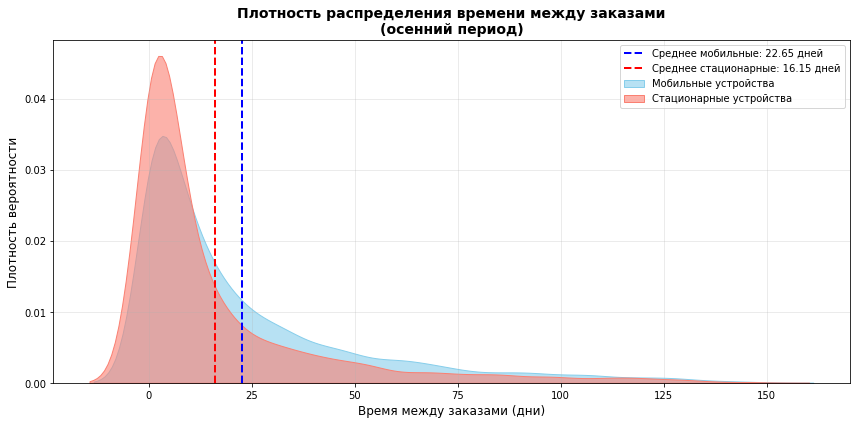

In [49]:
plt.figure(figsize=(12, 6))
sns.kdeplot(mobile_time, label='Мобильные устройства', fill=True, alpha=0.6, color='skyblue')
sns.kdeplot(desktop_time, label='Стационарные устройства', fill=True, alpha=0.6, color='salmon')

# Вертикальные линии со средними значениями
plt.axvline(mean_mobile_time, color='blue', linestyle='--', linewidth=2, label=f'Среднее мобильные: {mean_mobile_time:.2f} дней')
plt.axvline(mean_desktop_time, color='red', linestyle='--', linewidth=2, label=f'Среднее стационарные: {mean_desktop_time:.2f} дней')

# Настройка графика
plt.title('Плотность распределения времени между заказами\n(осенний период)', fontsize=14, fontweight='bold')
plt.xlabel('Время между заказами (дни)', fontsize=12)
plt.ylabel('Плотность вероятности', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Среднее время между заказами для мобильных устройств — 22.65 дня.
Для стационарных устройств — 16.15 дня.
Разница составляет ~6.5 дней — это существенная разница в поведении пользователей.

Форма распределения (по графику):
Распределения асимметричны, с длинным правым хвостом — большинство заказов совершается с небольшим интервалом, но есть пользователи с очень большими промежутками между заказами.
Пик плотности для стационарных устройств расположен левее (меньшие интервалы между заказами), чем для мобильных.
Мобильные устройства имеют более «растянутое» распределение — больше пользователей с длительными перерывами между заказами.

Размеры выборок:
Мобильные устройства: 9 903 наблюдения.
Стационарные устройства: 3 942 наблюдения.
Выборка мобильных устройств в ~2,5 раза больше, что повышает надёжность оценок для этой группы.

На основе данных подходит проведение t-теста Уэлча

In [50]:
alpha = 0.05

t_stat_time, p_value_time = ttest_ind(
    mobile_time,
    desktop_time,
    alternative='greater', 
    equal_var=False
)


if p_value_time < alpha:
    print("\nРезультат статистически значим (p < 0.05)")
    if mean_mobile_time > mean_desktop_time:
        print("Гипотеза подтверждена: среднее время между заказами на мобильных устройствах")
        print(f"({mean_mobile_time:.2f} дней) достоверно больше, чем на стационарных ({mean_desktop_time:.2f} дней).")
        print("Это означает, что пользователи делают заказы с мобильных устройств реже,")
        print("чем со стационарных.")
    else:
        print("Неожиданный результат: несмотря на значимое p‑значение, среднее")
        print("время на мобильных не больше. Проверьте данные.")
else:
    print("\nНет статистически значимых доказательств того, что время между заказами")
    print("на мобильных устройствах больше, чем на стационарных (p ≥ 0.05).")


Результат статистически значим (p < 0.05)
Гипотеза подтверждена: среднее время между заказами на мобильных устройствах
(22.65 дней) достоверно больше, чем на стационарных (16.15 дней).
Это означает, что пользователи делают заказы с мобильных устройств реже,
чем со стационарных.


Согласно результатам теста, среднее время между заказами у пользователей мобильных устройств значимо больше, чем у пользователей стационарных устройств. Это подтверждает исходную гипотезу исследования.

Количественная оценка различий
- Мобильные устройства: среднее время между заказами — 22.65 дня.
- Стационарные устройства: среднее время между заказами — 16.15 дня.
- Разница: 6.5 дней (или ~40 % относительно уровня стационарных устройств).
Это существенное различие в поведении пользователей: мобильные пользователи делают заказы реже.

## Общий вывод и рекомендации

Во время первичной обработки было осуществлено объединение двух датасетов events и orders.Первоначальный объем данных двух датасетов составил 290849 строк и 24 столбца. В ходе предобработки были обнарудены пропуски и дубликаты (пропуски в таблице events были удалены, пропуски days_since_prev оставлены без изменений). Столбцы с датами created_dt_msk,created_ts_msk, data преобразованы в тип datetime. Типы данных в таких столбцах как revenue, total, city_id, venue_id, days_since_prev были оптимизированы.

Явные дубликаты обнаружены не были. Неявных дубликатов выявлено 30 шт., которые в последствии были удалены.

Были созданы дополнительные столбцы revenue_rub — выручка с заказа в rub, one_ticket_revenue_rub — выручка с продажи одного билета на мероприятие, month — месяц оформления заказа, season — информация о сезонности, включая такие категории, как: 'лето', 'осень', 'зима', 'весна'.

После всех произведенных действия осталось строк в датасете 234905, процент потерь составил 19,23%.


Наиболее востребованные мероприятия:
- Концерты — абсолютные лидеры: летом их доля составляла 43,1 %, осенью снизилась до 38,7 %, но осталась самой высокой среди всех типов.
- Театральные постановки — заметный рост осенью: с 19,7 % летом до 25,7 % осенью (вероятно, из‑за открытия театрального сезона).
- Стендапы — более популярны летом (5,5 %), осенью спрос снизился до 4,4 %.
- Выставки — стабильно низкий спрос: 2,3 % летом и 1,6 % осенью.

2. Изменения популярности мероприятий осенью:

Смещение интереса от массовых развлекательных форматов (концерты, стендапы) к более «культурным» (театры). Рост спроса на мероприятия для семей с детьми (возрастной рейтинг 12+ вырос с 20,4 % летом до 22,8 % осенью). Стабильный высокий спрос на контент с рейтингом 16+ (28,5 % летом, 26,6 % осенью).

3. Изменение стоимости среднего чека:
Средняя стоимость билета осенью колеблется в диапазоне 120–200 руб., с заметными перепадами по дням. В выходные средний доход с заказа чуть выше, чем в будни (548 руб. против 509 руб.), несмотря на меньшую активность. Медианный чек ниже среднего (346,63 руб. для RUB), что указывает на наличие дорогих заказов, влияющих на среднее значение.

4. Информация из анализа пользовательской активности:
Рост общего числа заказов с июня по октябрь: от 29 097 в июне до 78 248 в октябре (+150 %). Пик активности — октябрь, вероятно, из‑за предпраздничных покупок, акций или запуска новых продуктов. По дням недели: максимальная активность в пятницу (2 515,5 заказов), минимальная — в воскресенье (1 835,8 заказов). Будни vs выходные: в будни больше заказов (2 273,7/день), но в выходные выше средний доход с заказа.

Устройства: 81 % заказов оформляются с мобильных устройств, доля стабильна летом и осенью.
Количество билетов в заказе: в среднем 2,75–2,76 билета, медиана — 3 билета. Большинство заказов (50 %) включают 2–4 билета.

5. Лидеры по числу заказов и выручке:

Регионы:
- Каменевский регион — явный лидер: 26,5 % мероприятий, 31,7 % заказов, высокая выручка.
- Широковская область — умеренный вклад (5,8 % заказов, 5,3 % выручки).
- Озернинский край — относительно низкий объём мероприятий (1,6 %), но заметная выручка (5,8 %) из‑за высокой конверсии.
- Светополянский округ — много мероприятий (4,8 %), но низкая выручка (1,8 %) — возможно, из‑за дешёвых билетов.


Сезонность спроса: летом преобладают массовые мероприятия (концерты), осенью — театральные постановки и семейный контент.

Ценовая динамика: средняя стоимость билета нестабильна, наблюдаются резкие скачки (до 200 руб.) и спады (до 120 руб.).

Аудитория: стабильный спрос на контент 16+, рост интереса к категории 12+ осенью. Категории 0+ и 18+ чувствительны к сезонным изменениям.

Гипотеза о доминировании мобильных устройств подтверждена: 81 % заказов стабильно через мобильные платформы. Согласно результатам теста, среднее время между заказами у пользователей мобильных устройств значимо больше, чем у пользователей стационарных устройств. Это подтверждает исходную гипотезу исследования.

**Рекомендации:**
1. Стратегические направления
Сфокусироваться на пиковых периодах. Уделить особое внимание октябрю — месяцу с максимальным спросом (+150 % к июню). Запускать масштабные рекламные кампании за 2–3 недели до мероприятий.
Учитывать сезонность форматов. Летом делать акцент на концерты и стендапы, осенью — на театральные постановки и семейный контент.
Развивать мобильное направление. Поскольку 81 % заказов оформляется через мобильные устройства, инвестировать в улучшение приложения и мобильного сайта.

2. Продуктовая политика
Расширить предложение театральных постановок осенью, когда спрос на них растёт на 6 % (с 19,7 % летом до 25,7 %).
Поддерживать высокий уровень предложения концертов — они остаются лидером спроса (38–43 %).
Стимулировать спрос на менее популярные форматы (выставки, стендапы) через партнёрские проекты и спецпрограммы.

3. Ценообразование и акции
Внедрить гибкие ценовые пакеты:
* скидки на групповые билеты (2–4 шт.);
* специальные предложения для пар (2 билета) и семей (3–4 билета).
* запускать акции в будние дни — активность ниже, чем в выходные, но средний чек близок к выходному, использовать промокоды, кешбэк и временные скидки.

Разработать программы лояльности — накопительные скидки, бонусы за повторные покупки, персональные предложения на основе истории заказов.

4. Активно применять цифровые каналы:
* email‑рассылки с анонсами и персональными рекомендациями;
* пуш‑уведомления о скидках и новинках;
* таргетированную рекламу в соцсетях.